In [2]:
# After running, restart the kernel before continuing.
%pip -q install --upgrade "sagemaker>=2,<3" boto3 botocore
%pip -q install "scikit-learn==1.4.2"
%pip -q install "xgboost>=2.0,<3" "imbalanced-learn>=0.12,<0.14"

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [1]:
# Standard Library Imports
import os

# 1. Suppress the SageMaker v2 deprecation warning
os.environ["SAGEMAKER_SUPPRESS_V2_WARNING"] = "1"

import gc
import json
import resource
import tempfile
from pathlib import Path

# Data & ML Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# XGBoost and Imbalanced-Learn
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Cloud & MLOps
import boto3
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient

# AWS SageMaker SDK
import sagemaker

print(f"SageMaker Version: {sagemaker.__version__}")
print(f"MLflow Version: {mlflow.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


SageMaker Version: 2.257.6
MLflow Version: 3.13.0


In [2]:
# Configuration
session = sagemaker.Session()
role = sagemaker.get_execution_role()

# ============================================================
# Student / team settings
# ============================================================
TEAM_ID = "team09"
STUDENT_ID = "s901"

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "bank-fraud-detection"
REGION = "ap-southeast-1"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# ============================================================
# MLflow App config
# ------------------------------------------------------------
# Preferred:
# 1. Team-level config copied/shared from Notebook 01A:
#       mlflow_app_config_team40.json
# 2. Student-specific config from Notebook 01A:
#       mlflow_app_config_team40_s4002.json
# 3. Any local config matching this team:
#       mlflow_app_config_team40_*.json
#
# Important:
# Do not use another team's MLflow ARN. With team-level IAM
# restriction, wrong-team access should fail with 403.
# ============================================================

TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT = f"{COURSE}/{TEAM_ID}/Experiment1"
mlflow_app_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_app_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = mlflow_app_config.get("MLFLOW_APP_ARN")
        MLFLOW_EXPERIMENT = mlflow_app_config.get("EXPERIMENT_NAME", MLFLOW_EXPERIMENT)
        config_used = config_file
        break

# Fallback for classroom testing only.
# Update this to your team's MLflow App ARN from Notebook 01A if the config file
# is not available in this Studio workspace.
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:" "mlflow-app/app-L5IMA5YSBDTY"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present
config_team_id = mlflow_app_config.get("TEAM_ID") or mlflow_app_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

REGISTERED_MODEL = f"iti113-{TEAM_ID}-{PROJECT_NAME}"
RANDOM_STATE = 42

print("=" * 70)
print("ITI113 Baseline Experiments — SageMaker MLflow App")
print("=" * 70)
print(f"Team               : {TEAM_ID}")
print(f"Student            : {STUDENT_ID}")
print(f"S3 Prefix          : {PREFIX}")
print(f"MLflow App ARN     : {MLFLOW_APP_ARN}")
print(f"MLflow Experiment  : {MLFLOW_EXPERIMENT}")
print(f"Registered Model   : {REGISTERED_MODEL}")
print(f"SageMaker Role     : {role}")
print("=" * 70)


Loaded MLflow App config from mlflow_app_config_team09_s901.json
ITI113 Baseline Experiments — SageMaker MLflow App
Team               : team09
Student            : s901
S3 Prefix          : iti113/team09/data/bank-fraud-detection
MLflow App ARN     : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YLZFIPQTQXFU
MLflow Experiment  : ITI113/team09/Experiment1
Registered Model   : iti113-team09-bank-fraud-detection
SageMaker Role     : arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team09


In [3]:
sm_client = boto3.client("sagemaker", region_name=REGION)

# ============================================================
# Safety check for team-level MLflow restriction
# ------------------------------------------------------------
# The selected MLflow App must have ResourceTag/TeamId = TEAM_ID.
# If a student accidentally uses another team's ARN, this should either:
# - fail with AccessDenied / 403 due to IAM restriction, or
# - fail this explicit validation before logging.
# ============================================================

try:
    tag_response = sm_client.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}
    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(
        f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}"
    )

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print(
        "1. The MLflow App ARN belongs to another team and IAM correctly blocked access."
    )
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

COMMON_TAGS = {
    "course": COURSE,
    "semester": SEMESTER,
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "team": TEAM_ID,  # kept for compatibility with previous notebooks
    "student": STUDENT_ID,  # kept for compatibility with previous notebooks
    "dataset": PROJECT_NAME,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_arn": MLFLOW_APP_ARN,
}

print(f"\nTracking URI : {mlflow.get_tracking_uri()}")

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
print(f"Experiment   : {exp.name}")
print(f"Experiment ID: {exp.experiment_id}")

# Optional: generate a presigned UI URL if the current role has permission.
try:
    url_response = sm_client.create_presigned_mlflow_app_url(Arn=MLFLOW_APP_ARN)
    mlflow_ui_url = (
        url_response.get("AuthorizedUrl")
        or url_response.get("Url")
        or url_response.get("PresignedUrl")
    )
    print("\nOpen the SageMaker MLflow UI:")
    print(mlflow_ui_url)
except Exception as e:
    print("\nCould not generate MLflow UI URL from this role/session.")
    print(type(e).__name__, e)


MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-8nb3rzhhmygx
  ProjectName: bank-fraud-detection
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-8nb3rzhhmygx/team09-shared
  Course: ITI113
  TeamId: team09
  CreatedByNotebook: 01A_fraud_setup_sagemaker_mlflow_app
  StudentId: s901
[OK] MLflow App tag TeamId=team09 matches notebook TEAM_ID=team09



Tracking URI : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YLZFIPQTQXFU
Experiment   : ITI113/team09/Experiment1
Experiment ID: 1



Open the SageMaker MLflow UI:
https://app-YLZFIPQTQXFU.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IlVSRTJZMyIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDNuc2NlL0x2UHowRzN1R0loTEVoQk9IOUVub0ZhRkNjekNEaEx1V3AxY1lBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFMk9GSXlVR2RzZW1SdGRUQjJaa2xOVGxwUGNVVndVbXhXTURaYWVHUTNTV0ZvWmsxalFqZExiRXR1ZDNWT1JtUTJjMHBHUkc1bmFEQnZMM0pyYlROWVVUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFmaTFvT1BabGpycmcwRDFzcEZOYkI0QUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6c1ZXd1BneEVVZ3l6MTYrVUNBUkNBT3pXdG85czYrUC9abGZySHBORWdIS0FHNW1zUG84OENQa1YvdmppcjFDZ2dIR1lZUUluaHFqUi9iWUxJWUFpSWltYmw3YmRuN0pEaHBOQ2RBZ0FBRUFDYkVRcGUvekxBYlFKdFZLRmFpUWQ2KytOdGVURHNRcDFncTlkOWhlRjd6OUcvUGoxdlF2N2Nx

In [5]:
#debugging, to remove

#if exp:
#    client.delete_experiment(exp.experiment_id)
#    print(f"Deleted experiment ID: {exp.experiment_id}")

TARGET_RUN_NAME = "sagemaker_pipeline_run"

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["metrics.test_pr_auc ASC"]
)



cols = [
    "tags.mlflow.runName",
    "metrics.test_roc_auc",
    "metrics.test_pr_auc",
    "run_id",
    "experiment_id",
]

avail = [c for c in cols if c in runs.columns]
print(runs[avail].to_string(index=False))
print(len(runs))


In [4]:
# Common function for memory usage observability
def current_memory_mb():
    """Peak resident memory of this process so far, in MB (Linux)."""
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024


def log_memory(label):
    print(f"[memory] {label}: {current_memory_mb():,.0f} MB (process peak RSS)")

In [5]:
# Common function to reduce memory in loading data
def reduce_memory(df, category_threshold=0.5, verbose=False):
    """Downcast numeric columns and convert low-cardinality strings to category, in place."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2 if verbose else None

    for col in df.columns:
        col_dtype = df[col].dtype

        if col_dtype == "object" or str(col_dtype) == "str":
            n_unique = df[col].nunique(dropna=True)
            n_total = len(df[col])
            if n_total > 0 and (n_unique / n_total) < category_threshold:
                df[col] = df[col].astype("category")
        elif pd.api.types.is_integer_dtype(col_dtype):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(col_dtype):
            if df[col].abs().max() < np.finfo(np.float32).max:
                df[col] = df[col].astype("float32")
    if verbose:
        end_mem = df.memory_usage(deep=True).sum() / 1024**2
        pct = 100 * (start_mem - end_mem) / start_mem if start_mem else 0
        print(f"Memory: {start_mem:.1f} MB -> {end_mem:,.1f} MB ({pct:.1f}% reduction)")
    return df


In [6]:
# Load processed dataset
def load_s3_csv(bucket, key, chunksize=200_000, dtype=None, downcast=True):
    """Stream an S3 CSV into pandas in chunks, downcasting each chunk before concatenating."""
    obj = s3.get_object(Bucket=bucket, Key=key)
    body = obj[
        "Body"
    ]  # file-like StreamingBody -> pandas reads it directly, no manual buffer copy

    chunks = []
    for chunk in pd.read_csv(body, dtype=dtype, chunksize=chunksize):
        if downcast:
            reduce_memory(
                chunk
            )  # numerics -> smallest int/float; low-cardinality strings -> category
        chunks.append(chunk)
    body.close()

    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    return df


s3 = boto3.client("s3")
p = f"{PREFIX}/processed"

# Features: mixed numeric + low-cardinality categorical -> let reduce_memory infer per column
X_train = load_s3_csv(BUCKET, f"{p}/train_features.csv")
X_val = load_s3_csv(BUCKET, f"{p}/val_features.csv")
X_test = load_s3_csv(BUCKET, f"{p}/test_features.csv")

# Labels: single 0/1 column -> force int8 directly, no downcast scan needed
y_train = load_s3_csv(
    BUCKET, f"{p}/train_labels.csv", dtype=np.int8, downcast=False
).squeeze("columns")
y_val = load_s3_csv(
    BUCKET, f"{p}/val_labels.csv", dtype=np.int8, downcast=False
).squeeze("columns")
y_test = load_s3_csv(
    BUCKET, f"{p}/test_labels.csv", dtype=np.int8, downcast=False
).squeeze("columns")

print(f"Train                   : {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Val                     : {X_val.shape[0]}  rows")
print(f"Test                    : {X_test.shape[0]}  rows")
print(f"Train fraud rate        : {y_train.mean()*100:.2f}%")
print(f"Val fraud rate          : {y_val.mean()*100:.2f}%")
print(f"Test fraud rate         : {y_test.mean()*100:.2f}%")
print(f"Total rows              : {len(X_train) + len(X_val) + len(X_test)}")

print(
    f"X_train memory (deep)   : {X_train.memory_usage(deep=True).sum() / 1024**2:,.1f} MB"
)


Train                   : 601002 rows, 46 features
Val                     : 199673  rows
Test                    : 199325  rows
Train fraud rate        : 5.52%
Val fraud rate          : 5.58%
Test fraud rate         : 5.49%
Total rows              : 1000000
X_train memory (deep)   : 63.6 MB


In [7]:
# Preprocessing setup
NUMERIC_FEATURES = [
    "hour_of_day",
    "customer_age",
    "credit_score",
    "account_age_years",
    "account_balance",
    "transaction_amount",
    "num_prev_transactions",
    "transaction_freq_monthly",
    "distance_from_home_km",
    "time_since_last_txn_hrs",
    "failed_attempts",
    "log_transaction_amount",
    "log_account_balance",
    "amount_to_balance_ratio",
    "risk_score",
    "failed_x_transaction",
    "night_x_international",
    "pin_x_failed",
    "night_x_pin",
    "amount_x_distance",
    "amount_x_failed",
    "risk_x_amount",
    "risk_x_distance",
    "customer_mean_amount",
    "customer_std_amount",
    "customer_mean_distance",
    "customer_std_distance",
    "customer_txn_count",
    "customer_mean_balance",
    "amount_zscore",
    "distance_zscore",
    "balance_deviation",
]
CATEGORICAL_FEATURES = [
    "is_weekend",
    "is_night_transaction",
    "country",
    "city",
    "merchant_category",
    "payment_method",
    "device_type",
    "is_international",
    "pin_changed_recently",
    "customer_age_group",
    "hour_bin",
    "high_amount",
    "far_from_home",
    "rapid_txn",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore", sparse_output=True, dtype=np.float32
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

print(f"Numerical features    : {len(NUMERIC_FEATURES)}")
print(f"Categorical features  : {len(CATEGORICAL_FEATURES)}")


Numerical features    : 32
Categorical features  : 14


In [8]:
# Helper functions
def _best_f1_threshold(y_true, y_prob):
    """Return the probability threshold that maximises the F1 score on y_true."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1 =  2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1))
    return float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5


def evaluate_model(model, X_tr, y_tr, X_val, y_val, X_te, y_te, tune_threshold=True):
    """Evaluate train/val/test and, optionally, pick a decision threshold on the validation set.

    With class_weight='balanced' on a 5.5% fraud dataset, the default 0.5 threshold
    predicts far too many positives and makes accuracy look bad (~50%). Tuning the threshold
    on validation gives a much better operating point for accuracy/F1.
    """
    metrics = {}
    threshold = 0.5

    if tune_threshold and X_val is not None and len(X_val) > 0:
        val_probs = model.predict_proba(X_val)[:, 1]
        threshold = _best_f1_threshold(y_val, val_probs)
        metrics['best_threshold'] = round(threshold, 4)

    for split, X, y in [('train', X_tr, y_tr), ('val', X_val, y_val), ('test', X_te, y_te)]:
        yb = model.predict_proba(X)[:, 1]
        yp = (yb >= threshold).astype(int)
        metrics.update(
            {
                f"{split}_accuracy"  : round(accuracy_score(y, yp), 4),
                f"{split}_f1"        : round(f1_score(y, yp, zero_division=0), 4),
                f"{split}_precision" : round(precision_score(y, yp, zero_division=0), 4),
                f"{split}_recall"    : round(recall_score(y, yp, zero_division=0), 4),
                f"{split}_roc_auc"   : round(roc_auc_score(y, yb), 4),
                f"{split}_pr_auc"    : round(average_precision_score(y, yb), 4),
            }
        )
    return metrics


def log_confusion_matrix(model, X, y, title, labels=['Non-Fraud', 'Fraud']):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model, X, y, display_labels=labels, cmap="Blues", ax=ax
    )
    ax.set_title(f"Confusion Matrix — {title}", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f"{tmp}/confusion_matrix.png"
        fig.savefig(p, dpi=100, bbox_inches="tight")
        mlflow.log_artifact(p, artifact_path="plots")
    plt.show()
    plt.close()


def log_roc_pr_curve(model, X, y, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    RocCurveDisplay.from_estimator(model, X, y, ax=ax[0])
    ax[0].plot([0, 1], [0, 1], "k--", label="Random baseline")
    ax[0].set_title(f"ROC Curve — {title}", fontweight="bold")
    ax[0].legend()
    PrecisionRecallDisplay.from_estimator(model, X, y, ax=ax[1], name=title)
    plt.suptitle(f"{title} - Test Set", y=1.02)
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f"{tmp}/roc_curve.png"
        fig.savefig(p, dpi=100, bbox_inches="tight")
        mlflow.log_artifact(p, artifact_path="plots")
    plt.show()
    plt.close()


def log_feature_importance(model, title):
    clf = model.named_steps["clf"]
    if not hasattr(clf, "feature_importances_"):
        return
    prep = model.named_steps["prep"]
    names = prep.get_feature_names_out()
    imp = pd.Series(clf.feature_importances_, index=names).sort_values(ascending=True).tail(20)
    fig, ax = plt.subplots(figsize=(8, 10))
    imp.plot(kind="barh", ax=ax, color="#5B9BD5")
    ax.set_title(f"Top 20 Feature Importance — {title}", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f"{tmp}/feature_importance.png"
        fig.savefig(p, dpi=100, bbox_inches="tight")
        mlflow.log_artifact(p, artifact_path="plots")
    plt.show()
    plt.close()


print("Helper functions ready.")

Helper functions ready.


In [ ]:
# Baseline - Logistic regression
run_name = f"{TEAM_ID}_{STUDENT_ID}_logistic_regression_baseline"

LR_PARAMS = {
    "C": 1.0,
    "max_iter": 1000,
    "solver": "lbfgs",
    "random_state": RANDOM_STATE,
}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags(COMMON_TAGS)
    mlflow.log_params(
        {
            **LR_PARAMS,
            "model_type": "LogisticRegression",
            "n_features": X_train.shape[1],
            "train_size": X_train.shape[0],
        }
    )
    pipe_lr = Pipeline(
        [("prep", preprocessor), ("clf", LogisticRegression(**LR_PARAMS))]
    )
    pipe_lr.fit(X_train, y_train)

    metrics = evaluate_model(pipe_lr, X_train, y_train, X_val, y_val, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(pipe_lr, X_test, y_test, "Logistic Regression")
    log_roc_pr_curve(pipe_lr, X_test, y_test, "Logistic Regression")
    mlflow.sklearn.log_model(pipe_lr, name="model")
    LR_RUN_ID = run.info.run_id

print("LOGISTIC REGRESSION RESULTS")
for k, v in sorted(metrics.items()):
    print(f'  {k:<25}: {v}')
print(f"Run ID: {LR_RUN_ID}")

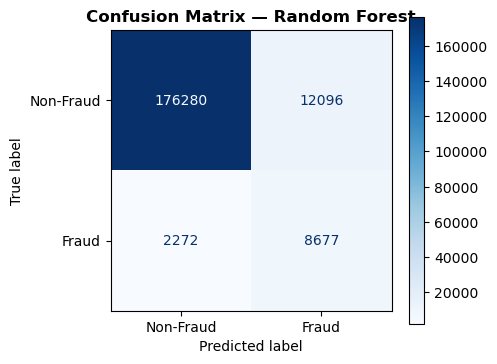

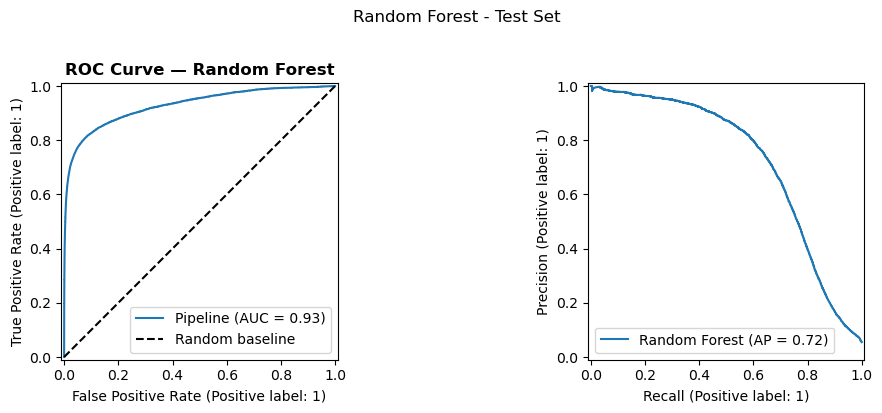

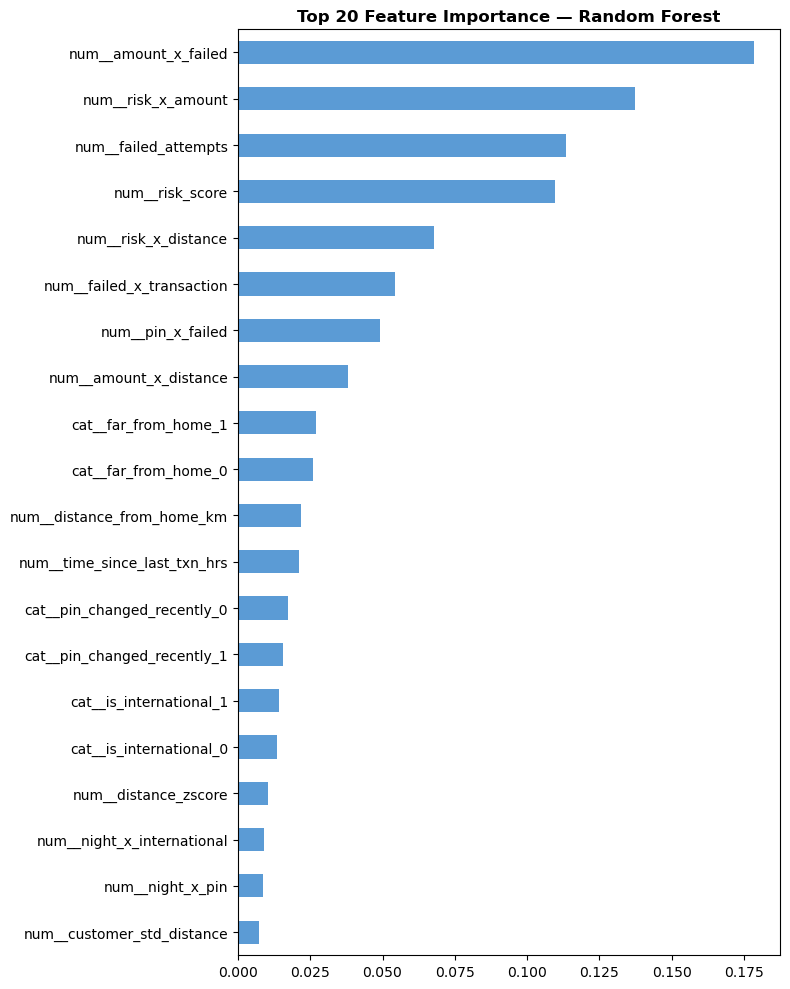

2026/08/25 14:07:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run team09_s901_random_forest_baseline at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/3753cba466ac4e398b07dc62965f519c
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
RANDOM FOREST RESULTS
  best_threshold           : 0.7805
  test_accuracy            : 0.9681
  test_f1                  : 0.6889
  test_pr_auc              : 0.7234
  test_precision           : 0.7411
  test_recall              : 0.6435
  test_roc_auc             : 0.9287
  train_accuracy           : 0.9697
  train_f1                 : 0.716
  train_pr_auc             : 0.7666
  train_precision          : 0.7409
  train_recall             : 0.6926
  train_roc_auc            : 0.9383
  val_accuracy             : 0.9685
  val_f1                   : 0.6958
  val_pr_auc               : 0.7283
  val_precision            : 0.7541
  val_recall               : 0.6458
  val_roc_auc              : 0.93
Run ID: 3753cba466ac4e398b07dc62965f519c


In [9]:
# Baseline - Random Forest
run_name = f"{TEAM_ID}_{STUDENT_ID}_random_forest_baseline"

RF_PARAMS = {
    "n_estimators": 100,
    "max_depth": 10,
    "min_samples_leaf": 2,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags(COMMON_TAGS)
    mlflow.log_params(
        {
            **RF_PARAMS,
            "model_type": "RandomForestClassifier",
            "n_features": X_train.shape[1],
            "train_size": X_train.shape[0],
        }
    )
    pipe_rf = Pipeline(
        [("prep", preprocessor), ("clf", RandomForestClassifier(**RF_PARAMS))]
    )
    pipe_rf.fit(X_train, y_train)

    metrics = evaluate_model(pipe_rf, X_train, y_train, X_val, y_val, X_test, y_test)
    mlflow.log_metrics(metrics)
    log_confusion_matrix(pipe_rf, X_test, y_test, "Random Forest")
    log_roc_pr_curve(pipe_rf, X_test, y_test, "Random Forest")
    log_feature_importance(pipe_rf, "Random Forest")
    mlflow.sklearn.log_model(pipe_rf, name="model")
    RF_RUN_ID = run.info.run_id

print("RANDOM FOREST RESULTS")
for k, v in sorted(metrics.items()):
    print(f"  {k:<25}: {v}")
print(f"Run ID: {RF_RUN_ID}")

In [9]:
class PreprocessedModel(BaseEstimator, ClassifierMixin):
    _estimator_type = "classifier"

    def __init__(self, preprocessor, clf):
        self.preprocessor = preprocessor
        self.clf = clf
        # Expose classes_ so scikit-learn knows it is a fitted classifier
        if hasattr(clf, "classes_"):
            self.classes_ = clf.classes_
        else:
            self.classes_ = np.array([0, 1])

    def fit(self, X, y):
        X_prep = self.preprocessor.fit_transform(X)
        self.clf.fit(X_prep, y)
        self.classes_ = getattr(self.clf, "classes_", np.array([0, 1]))
        return self

    def predict(self, X):
        X_prep = self.preprocessor.transform(X)
        return self.clf.predict(X_prep)

    def predict_proba(self, X):
        X_prep = self.preprocessor.transform(X)
        return self.clf.predict_proba(X_prep)

    # Expose named_steps so log_feature_importance continues to work smoothly
    @property
    def named_steps(self):
        return {"prep": self.preprocessor, "clf": self.clf}


def log_confusion_matrix_xgb(model, X, y, title, labels=['Non-Fraud', 'Fraud']):
    fig, ax = plt.subplots(figsize=(5, 4))

    # Compute predictions using custom model class
    y_pred = model.predict(X)

    ConfusionMatrixDisplay.from_predictions(
        y_true=y,
        y_pred=y_pred,
        display_labels=labels,
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Confusion Matrix — {title}", fontweight="bold")
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f"{tmp}/confusion_matrix.png"
        fig.savefig(p, dpi=100, bbox_inches="tight")
        mlflow.log_artifact(p, artifact_path="plots")
    plt.show()
    plt.close()


def log_roc_pr_curve_xgb(model, X, y, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    # Compute probability scores for positive class
    y_prob = model.predict_proba(X)[:, 1]

    RocCurveDisplay.from_predictions(
        y_true=y,
        y_pred=y_prob,
        ax=ax[0],
        name=title
    )
    ax[0].plot([0, 1], [0, 1], "k--", label="Random baseline")
    ax[0].set_title(f"ROC Curve — {title}", fontweight="bold")
    ax[0].legend()

    PrecisionRecallDisplay.from_predictions(
        y_true=y,
        y_pred=y_prob,
        ax=ax[1],
        name=title
    )
    plt.suptitle(f"{title} - Test Set", y=1.02)
    plt.tight_layout()
    with tempfile.TemporaryDirectory() as tmp:
        p = f"{tmp}/roc_curve.png"
        fig.savefig(p, dpi=100, bbox_inches="tight")
        mlflow.log_artifact(p, artifact_path="plots")
    plt.show()
    plt.close()

In [13]:
# XGBoost with scale_pos_weight (no SMOTE) - handles imbalance natively
run_name = f"{TEAM_ID}_{STUDENT_ID}_xgboost_scale_pos_weight"

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pw = n_neg / n_pos
print(f"Class distribution: {n_neg} non-fraud, {n_pos} fraud")
print(f"scale_pos_weight = {scale_pw:.2f}")

EARLY_STOPPING_ROUNDS = 30

XGB_PARAMS = {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.05,
    "scale_pos_weight": scale_pw,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags(COMMON_TAGS)
    mlflow.log_params(
        {
            **XGB_PARAMS,
            "model_type": "XGBClassifier",
            "imbalance_strategy": "scale_pos_weight",
            "scale_pos_weight": round(scale_pw, 2),
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            "n_features": X_train.shape[1],
            "train_size": X_train.shape[0],
        }
    )

    # Preprocess first so we can pass eval_set for early stopping
    X_train_prep = preprocessor.fit_transform(X_train)
    X_val_prep = preprocessor.transform(X_val)
    X_test_prep = preprocessor.transform(X_test)

    clf_xgb = XGBClassifier(**XGB_PARAMS)
    clf_xgb.fit(
        X_train_prep, y_train,
        eval_set=[(X_val_prep, y_val)],
        verbose=False,
    )
    print(
        f"Early stopping: best iteration {clf_xgb.best_iteration} / {XGB_PARAMS['n_estimators']}"
    )

    pipe_xgb = PreprocessedModel(preprocessor, clf_xgb)

    metrics = evaluate_model(pipe_xgb, X_train, y_train, X_val, y_val, X_test, y_test)
    print(metrics)
    mlflow.log_metrics(metrics)
    log_confusion_matrix_xgb(pipe_xgb, X_test, y_test, "XGBoost (scale_pos_weight)")
    log_roc_pr_curve_xgb(pipe_xgb, X_test, y_test, "XGBoost (scale_pos_weight)")
    log_feature_importance(pipe_xgb, "XGBoost (scale_pos_weight)")
    mlflow.sklearn.log_model(pipe_xgb, name="model")
    XGB_RUN_ID = run.info.run_id

print("XGBOOST (scale_pos_weight) RESULTS")
for k, v in sorted(metrics.items()):
    print(f"  {k:<25}: {v}")
print(f"Run ID: {XGB_RUN_ID}")

In [10]:
# SMOTE XGBoost parameters and strategy
SMOTE_XGB_PARAMS = {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.1,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "early_stopping_rounds": 30,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

# SMOTE sampling_strategy=0.5 means minority will be 5% of majority count
# This creates a 2:1 ratio (non-fraud:fraud) instead of the original 17:1
SMOTE_STRATEGY = 0.5
EARLY_STOPPING_ROUNDS = 30

SMOTE: 601002 -> 851749 rows


Early stopping: best iteration 199 / 200


{'best_threshold': 0.9288, 'train_accuracy': 0.9717, 'train_f1': 0.7188, 'train_precision': 0.7952, 'train_recall': 0.6558, 'train_roc_auc': 0.9404, 'train_pr_auc': 0.7634, 'val_accuracy': 0.9709, 'val_f1': 0.7126, 'val_precision': 0.7943, 'val_recall': 0.6462, 'val_roc_auc': 0.9304, 'val_pr_auc': 0.7526, 'test_accuracy': 0.9707, 'test_f1': 0.7078, 'test_precision': 0.783, 'test_recall': 0.6458, 'test_roc_auc': 0.9297, 'test_pr_auc': 0.7489}


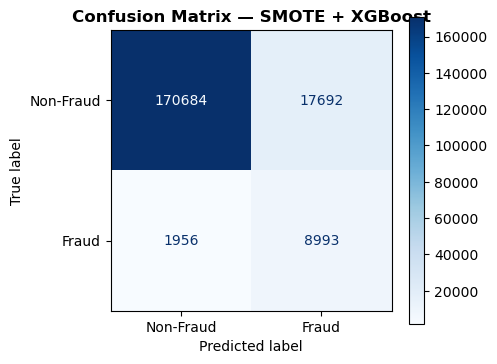

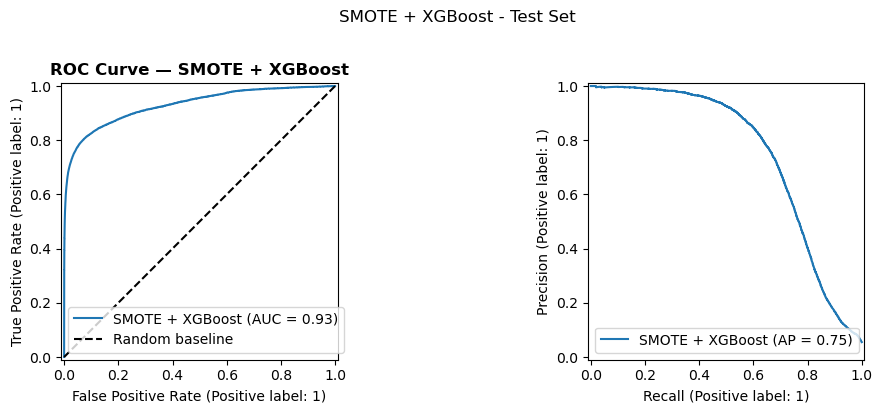

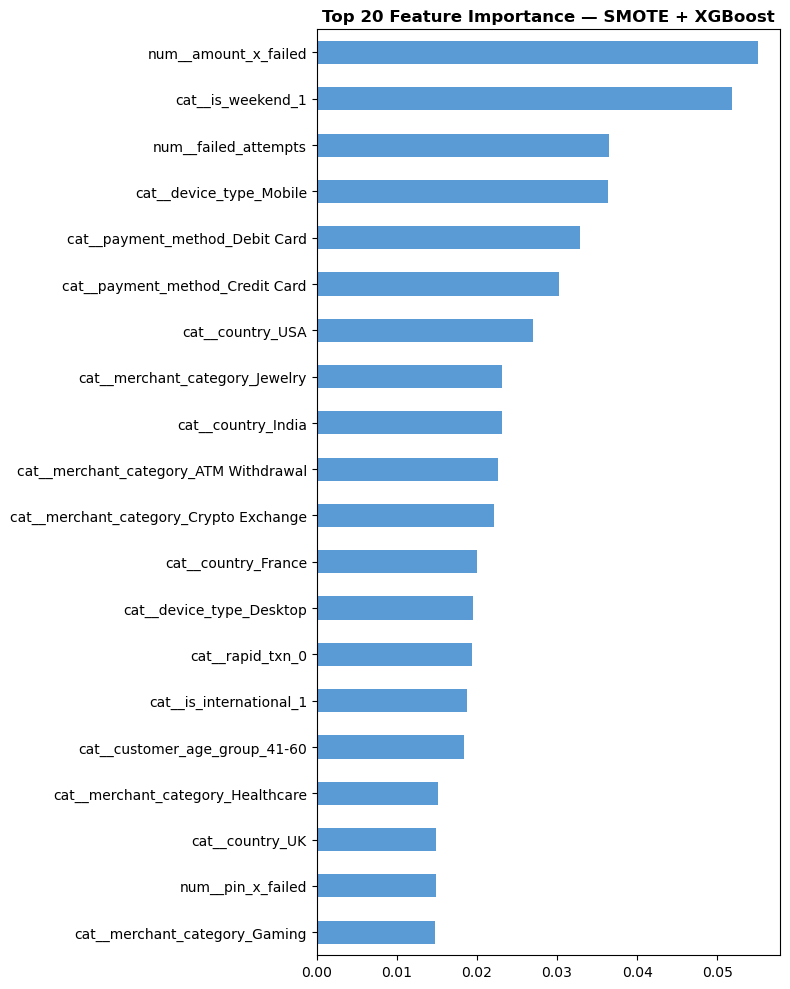

2026/08/25 14:20:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run team09_s901_smote_xgboost at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/0a9fc3ce72d545a0a0ca57168f1f07c4
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
SMOTE + XGBOOST RESULTS
  best_threshold           : 0.9288
  test_accuracy            : 0.9707
  test_f1                  : 0.7078
  test_pr_auc              : 0.7489
  test_precision           : 0.783
  test_recall              : 0.6458
  test_roc_auc             : 0.9297
  train_accuracy           : 0.9717
  train_f1                 : 0.7188
  train_pr_auc             : 0.7634
  train_precision          : 0.7952
  train_recall             : 0.6558
  train_roc_auc            : 0.9404
  val_accuracy             : 0.9709
  val_f1                   : 0.7126
  val_pr_auc               : 0.7526
  val_precision            : 0.7943
  val_recall               : 0.6462
  val_roc_auc              : 0.9304
Run ID: 0a9fc3ce72d545a0a0ca57168f1f07c4


In [15]:
# SMOTE + XGBoost - SMOTE oversample minority class, then train XBGoost
run_name = f"{TEAM_ID}_{STUDENT_ID}_smote_xgboost"

with mlflow.start_run(run_name=run_name) as run:
    mlflow.set_tags(COMMON_TAGS)
    mlflow.log_params(
        {
            **SMOTE_XGB_PARAMS,
            "model_type": "XGBClassifier",
            "imbalance_strategy": f"SMOTE(strategy={SMOTE_STRATEGY})",
            "smote_sampling_strategy": SMOTE_STRATEGY,
            "n_features": X_train.shape[1],
            "train_size": X_train.shape[0],
        }
    )

    # Preprocess first so we can pass eval_set for early stopping
    prep = preprocessor.fit(X_train)
    X_train_prep = prep.transform(X_train)
    X_val_prep = prep.transform(X_val)

    # SMOTE on training data only
    smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_STRATEGY)
    X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)
    print(f"SMOTE: {X_train_prep.shape[0]} -> {X_train_res.shape[0]} rows")

    # XGBoost with early stopping on un-resampled validation set
    clf_xgb = XGBClassifier(**XGB_PARAMS)
    clf_xgb.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val_prep, y_val)],
        verbose=False,
    )
    print(
        f"Early stopping: best iteration {clf_xgb.best_iteration} / {XGB_PARAMS['n_estimators']}"
    )

    pipe_smote_xgb = PreprocessedModel(preprocessor, clf_xgb)

    metrics = evaluate_model(
        pipe_smote_xgb, X_train, y_train, X_val, y_val, X_test, y_test
    )
    print(metrics)
    mlflow.log_metrics(metrics)
    log_confusion_matrix_xgb(pipe_smote_xgb, X_test, y_test, "SMOTE + XGBoost")
    log_roc_pr_curve_xgb(pipe_smote_xgb, X_test, y_test, "SMOTE + XGBoost")
    log_feature_importance(pipe_smote_xgb, "SMOTE + XGBoost")
    mlflow.sklearn.log_model(pipe_smote_xgb, name="model")
    SMOTE_XGB_RUN_ID = run.info.run_id

print("SMOTE + XGBOOST RESULTS")
for k, v in sorted(metrics.items()):
    print(f"  {k:<25}: {v}")
print(f"Run ID: {SMOTE_XGB_RUN_ID}")

In [11]:
# xgb tuning, with early stopping
xgb_param_grid = [
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "min_child_weight": 3,
    },
    {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 5,
    },
    {
        "n_estimators": 300,
        "max_depth": 8,
        "learning_rate": 0.05,
        "min_child_weight": 5
    },
    {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.03,
        "min_child_weight": 3,
    },
    {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.03,
        "min_child_weight": 5,
    },
]

best_val_pr_auc, best_xgb_model, best_xgb_params = 0, None, None

# Preprocess first so we can pass eval_set for early stopping
prep_tuning = preprocessor.fit(X_train)
X_train_prep_t = prep_tuning.transform(X_train)
X_val_prep_t = prep_tuning.transform(X_val)

# SMOTE on training data only
smote_tuning = SMOTE(random_state=RANDOM_STATE, sampling_strategy=SMOTE_STRATEGY)
X_train_res_t, y_train_res_t = smote_tuning.fit_resample(X_train_prep_t, y_train)
print(f"SMOTE for tuning: {X_train_prep_t.shape[0]} -> {X_train_res_t.shape[0]} rows")

with mlflow.start_run(
    run_name=f"{TEAM_ID}_{STUDENT_ID}_xgb_smote_tuning_parent"
) as parent:

    mlflow.set_tags(COMMON_TAGS)
    mlflow.log_param("n_candidates", len(xgb_param_grid))
    mlflow.log_param("imbalance_strategy", f"SMOTE(strategy={SMOTE_STRATEGY})")

    for i, params in enumerate(xgb_param_grid):
        all_p = {
            **params,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "gamma": 0.1,
            "reg_alpha": 0.1,
            "reg_lambda": 1.0,
            "eval_metric": "aucpr",
            "tree_method": "hist",
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
        with mlflow.start_run(run_name=f"xgb_smote_candidate_{i+1:02d}", nested=True):
            mlflow.log_params(all_p)

            # XGBoost with early stopping on un-resampled validation set
            clf = XGBClassifier(**all_p)
            clf.fit(
                X_train_res_t, y_train_res_t,
                eval_set=[(X_val_prep_t, y_val)],
                verbose=False,
            )

            print(
                f"Early stopping: best iteration {clf.best_iteration} / {params['n_estimators']}"
            )

            m = PreprocessedModel(prep_tuning, clf)
            val_m = evaluate_model(m, X_train, y_train, X_val, y_val, X_test, y_test)
            mlflow.log_metrics(val_m)
            # log model artifact for this candidate run
            mlflow.sklearn.log_model(m, name="model")

            print(
                f'Candidate {i+1}: depth={params["max_depth"]}, lr={params["learning_rate"]}, '
                f'n_est={params["n_estimators"]} | '
                f'val PR-AUC={val_m["val_pr_auc"]} | val Recall={val_m["val_recall"]} | '
                f'val Precision={val_m["val_precision"]} | test PR-AUC={val_m["test_pr_auc"]} | '
                f'test Recall={val_m["test_recall"]} | test Precision={val_m["test_precision"]}'
            )
            if val_m["val_pr_auc"] > best_val_pr_auc:
                best_val_pr_auc, best_xgb_model, best_xgb_params = (
                    val_m["val_pr_auc"],
                    m,
                    all_p,
                )

    mlflow.log_metric("best_val_pr_auc", round(best_val_pr_auc, 4))
    mlflow.log_params({"best_params": json.dumps(best_xgb_params)})
    XGB_TUNING_RUN_ID = parent.info.run_id

print(f"\nBest val PR-AUC : {best_val_pr_auc:.4f}")
print(f"Best params : {best_xgb_params}")

SMOTE for tuning: 601002 -> 851749 rows


Early stopping: best iteration 297 / 300


2026/08/27 07:59:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Candidate 1: depth=4, lr=0.05, n_est=300 | val PR-AUC=0.7549 | val Recall=0.6441 | val Precision=0.8037 | test PR-AUC=0.7511 | test Recall=0.646 | test Precision=0.7904
🏃 View run xgb_smote_candidate_01 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/fcc3b0a746334b3692e980b7d93df264
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Early stopping: best iteration 149 / 300


...

Candidate 4: depth=6, lr=0.03, n_est=500 | val PR-AUC=0.7592 | val Recall=0.6501 | val Precision=0.8015 | test PR-AUC=0.7557 | test Recall=0.6517 | test Precision=0.79
🏃 View run xgb_smote_candidate_04 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/af0cb8fd789642878d00895bd69adff8
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


Early stopping: best iteration 498 / 500


2026/08/27 08:19:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Candidate 5: depth=8, lr=0.03, n_est=500 | val PR-AUC=0.7595 | val Recall=0.6487 | val Precision=0.808 | test PR-AUC=0.7566 | test Recall=0.65 | test Precision=0.7965
🏃 View run xgb_smote_candidate_05 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/57f071b6a27047c9899c576b2e1c0031
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1


🏃 View run team09_s901_xgb_smote_tuning_parent at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/8359888762e640228feb9c469fb97a89
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1

Best val PR-AUC : 0.7595
Best params : {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'eval_metric': 'aucpr', 'tree_method': 'hist', 'early_stopping_rounds': 30, 'random_state': 42, 'n_jobs': -1}


In [ ]:
param_grid = [
    {"n_estimators": 100, "max_depth": 15, "min_samples_leaf": 2},
    {"n_estimators": 150, "max_depth": 10, "min_samples_leaf": 2},
    {"n_estimators": 150, "max_depth": 15, "min_samples_leaf": 4},
    {"n_estimators": 200, "max_depth": 10, "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": 15, "min_samples_leaf": 4},
]

best_val_auc, best_model, best_params = 0, None, None

with mlflow.start_run(run_name=f"{TEAM_ID}_{STUDENT_ID}_rf_tuning_parent") as parent:

    mlflow.set_tags(COMMON_TAGS)

    mlflow.log_param("n_candidates", len(param_grid))
    mlflow.log_param("cv_folds", 5)

    for i, params in enumerate(param_grid):
        all_p = {
            **params,
            "class_weight": "balanced",
            "random_state": RANDOM_STATE,
            "n_jobs": -1,
        }
        with mlflow.start_run(run_name=f"rf_candidate_{i+1:02d}", nested=True):
            mlflow.log_params(all_p)
            m = Pipeline(
                [("prep", preprocessor), ("clf", RandomForestClassifier(**all_p))]
            )
            m.fit(X_train, y_train)
            val_m = evaluate_model(m, X_train, y_train, X_val, y_val, X_test, y_test)
            mlflow.log_metrics(val_m)
            # log model artifact for this candidate run
            mlflow.sklearn.log_model(m, name="model")

            print(
                f'Candidate {i+1}: {params}, | '
                f'val PR-AUC={val_m["val_pr_auc"]} | val Recall={val_m["val_recall"]} | '
                f'val Precision={val_m["val_precision"]} | test PR-AUC={val_m["test_pr_auc"]} | '
                f'test Recall={val_m["test_recall"]} | test Precision={val_m["test_precision"]}'
            )
            if val_m["val_pr_auc"] > best_val_auc:
                best_val_auc, best_model, best_params = val_m["val_roc_auc"], m, all_p

    mlflow.log_metric("best_cv_auc", round(best_val_auc, 4))
    mlflow.log_params({"best_params": json.dumps(best_params)})
    TUNING_RUN_ID = parent.info.run_id

print(f"\nBest val ROC-AUC : {best_val_auc:.4f}")
print(f"Best params : {best_params}")

In [14]:
%pip -q install "shap>=0.43,<1"

In [ ]:
import shap
print(f"SHAP Version: {shap.__version__}")

# SHAP Explainability Analysis for best XGBoost model
# Get the underlying XGBoost classifier from the PreprocessedModel wrapper
clf_for_shap = best_xgb_model.named_steps["clf"]
prep_for_shap = best_xgb_model.named_steps["prep"]

# Preprocess a sample of test data (1000 rows for speed)
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
X_test_prep_shap = prep_for_shap.transform(X_test_sample)

# Get feature names from the preprocessor
feature_names = prep_for_shap.get_feature_names_out()

# TreeExplainer: exact SHAP values for tree models (fast, no approximation)
explainer = shap.TreeExplainer(clf_for_shap)
shap_values = explainer.shap_values(X_test_prep_shap)

print(f"Shap values shape: {shap_values.shape}")
print(f"Features: {len(feature_names)}")

# SHAP Summary Plot (global feature importance with direction)
# Each dot is a sample; x-axis= SHAP value (impact on prediction)
print("\n--- SHAP Summary Plot (bee swarm)")
fig, ax = plt.subplots(figsize=(10, 12))
shap.summary_plot(shap_values, X_test_prep_shap, feature_names=feature_names,
                  max_display=25, show=False)
plt.title("SHAP Summary Plot - Top 25 Features", fontweight="bold", pad=20)
plt.tight_layout()
with tempfile.TemporaryDirectory() as tmp:
    p = f"{tmp}/shap_summary.png"
    plt.savefig(p, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(p, artifact_path="plots")
plt.show()
plt.close()

# 2. SHAP Bar Plot (mean absolute SHAP value per feature)
print("\n--- SHAP Feature Importance (mean |SHAP|) ---")
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_prep_shap, feature_names=feature_names,
                  plot_type="bar", max_display=25, show=False)
plt.title("SHAP Feature Importance - Top 25 Features", fontweight="bold", pad=20)
plt.tight_layout()
with tempfile.TemporaryDirectory() as tmp:
    p = f"{tmp}/shap_bar.png"
    plt.savefig(p, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(p, artifact_path="plots")
plt.show()
plt.close()

# 3. SHAP values for a single high-risk prediction (local explanation)
probs_sample = clf_for_shap.predict_proba(X_test_prep_shap)[:, 1]
high_risk_idx = probs_sample.argmax()
print(f"\n --- Local Explanation: highest-risk transaction (prob={probs_sample[high_risk_idx]:.3f}) ---")

# X_test_prep_shap may be sparse (OneHotEncoder output) — densify the single row
row_data = X_test_prep_shap[high_risk_idx]
if hasattr(row_data, "toarray"):
    row_data = row_data.toarray().ravel()

explanation = shap.Explanation(
    values=shap_values[high_risk_idx, :],
    base_values=explainer.expected_value,
    data=row_data,
    feature_names=feature_names,
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f"SHAP Waterfall - Single Transaction (fraud prob={probs_sample[high_risk_idx]:.3f})",
          fontweight="bold")
plt.tight_layout()
with tempfile.TemporaryDirectory() as tmp:
    p = f"{tmp}/shap_waterfall_plot.png"
    plt.savefig(p, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(p, artifact_path="plots")
plt.show()
plt.close()

In [ ]:
import shap
print(f"SHAP Version: {shap.__version__}")

# SHAP Explainability Analysis for best XGBoost model
# Get the underlying XGBoost classifier from the PreprocessedModel wrapper
clf_for_shap = best_xgb_model.named_steps["clf"]
prep_for_shap = best_xgb_model.named_steps["prep"]

# Preprocess a sample of test data (1000 rows for speed)
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=RANDOM_STATE)
X_test_prep_shap = prep_for_shap.transform(X_test_sample)

# Get feature names from the preprocessor
feature_names = prep_for_shap.get_feature_names_out()

# TreeExplainer: exact SHAP values for tree models (fast, no approximation)
explainer = shap.TreeExplainer(clf_for_shap)
shap_values = explainer.shap_values(X_test_prep_shap)

print(f"Shap values shape: {shap_values.shape}")
print(f"Features: {len(feature_names)}")

# SHAP Summary Plot (global feature importance with direction)
# Each dot is a sample; x-axis= SHAP value (impact on prediction)
print("\n--- SHAP Summary Plot (bee swarm)")
fig, ax = plt.subplots(figsize=(10, 12))
shap.summary_plot(shap_values, X_test_prep_shap, feature_names=feature_names,
                  max_display=25, show=False)
plt.title("SHAP Summary Plot - Top 25 Features", fontweight="bold", pad=20)
plt.tight_layout()
with tempfile.TemporaryDirectory() as tmp:
    p = f"{tmp}/shap_summary.png"
    plt.savefig(p, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(p, artifact_path="plots")
plt.show()
plt.close()

# 2. SHAP Bar Plot (mean absolute SHAP value per feature)
print("\n--- SHAP Feature Importance (mean |SHAP|) ---")
fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_prep_shap, feature_names=feature_names,
                  plot_type="bar", max_display=25, show=False)
plt.title("SHAP Feature Importance - Top 25 Features", fontweight="bold", pad=20)
plt.tight_layout()
with tempfile.TemporaryDirectory() as tmp:
    p = f"{tmp}/shap_bar.png"
    plt.savefig(p, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(p, artifact_path="plots")
plt.show()
plt.close()

# 3. SHAP values for a single high-risk prediction (local explanation)
probs_sample = clf_for_shap.predict_proba(X_test_prep_shap)[:, 1]
high_risk_idx = probs_sample.argmax()
print(f"\n --- Local Explanation: highest-risk transaction (prob={probs_sample[high_risk_idx]:.3f}) ---")

# X_test_prep_shap may be sparse (OneHotEncoder output) — densify the single row
row_data = X_test_prep_shap[high_risk_idx]
if hasattr(row_data, "toarray"):
    row_data = row_data.toarray().ravel()

explanation = shap.Explanation(
    values=shap_values[high_risk_idx, :],
    base_values=explainer.expected_value,
    data=row_data,
    feature_names=feature_names,
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f"SHAP Waterfall - Single Transaction (fraud prob={probs_sample[high_risk_idx]:.3f})",
          fontweight="bold")
plt.tight_layout()
with tempfile.TemporaryDirectory() as tmp:
    p = f"{tmp}/shap_waterfall_plot.png"
    plt.savefig(p, dpi=100, bbox_inches="tight")
    mlflow.log_artifact(p, artifact_path="plots")
plt.show()
plt.close()

## SHAP Explainability Analysis — Key Findings

**Model:** XGBoost (scale_pos_weight, no SMOTE)
**Method:** TreeExplainer on a 1,000-row sample of the test set

### Global Feature Importance

The model's fraud predictions are dominated by a small set of **engineered interaction features** rather than raw transaction attributes:

| Rank | Feature | Insight |
|------|---------|---------|
| 1 | `num__failed_attempts` | By far the strongest single predictor — high failed-attempt counts drive fraud probability up sharply |
| 2 | `num__risk_x_distance` | Second strongest — combining risk score with geographic distance captures fraud patterns neither feature alone would catch |
| 3 | `num__risk_x_amount` | High risk score combined with high transaction amount pushes predictions toward fraud |
| 4 | `num__amount_x_failed` | Large amounts paired with failed attempts is a strong fraud signal |
| 5 | `num__time_since_last_txn_hrs` | Bidirectional — both very short and very long gaps since the last transaction show some predictive signal, unlike the cleanly one-directional features above |
| 6 | `num__risk_score` | Base risk score remains predictive on its own, independent of the interaction terms built from it |

**Lower-impact but directionally sensible features:** `is_international`, `country_USA`, `merchant_category_Crypto Exchange`, `merchant_category_ATM Withdrawal`, and `device_type` — all nudge predictions toward fraud when present, consistent with domain expectations, but contribute far less individually than the engineered interaction terms.

### Takeaway on Feature Engineering

The interaction features (`risk_x_distance`, `risk_x_amount`, `amount_x_failed`, `pin_x_failed`, `failed_x_transaction`) collectively outrank almost every raw column. This indicates the feature engineering step — multiplying risk/amount/failed-attempt signals together — is capturing fraud patterns that the raw features alone do not, and is doing much of the heavy lifting for the model.

### Local Explanation — Highest-Risk Transaction (fraud probability = 0.999)

Starting from the base rate **E[f(X)] = -0.701** (log-odds space), the model builds up to a final score of **f(x) = 7.49** almost entirely through a handful of features:

| Feature | Value | SHAP Contribution |
|---|---|---|
| `num__failed_attempts` | 5.799 | **+3.77** (dominant driver) |
| `num__risk_x_distance` | 4.636 | +1.46 |
| `num__risk_x_amount` | 4.502 | +0.79 |
| `num__amount_x_failed` | 6.903 | +0.75 |
| `num__risk_score` | 3.643 | +0.65 |
| `num__pin_x_failed` | 11.247 | +0.55 |
| `num__failed_x_transaction` | 10.05 | +0.34 |
| `num__time_since_last_txn_hrs` | -0.722 | +0.26 |
| `cat__city_Toronto` | 1 | -0.22 |
| `num__amount_x_distance` | 2.679 | +0.22 |
| `cat__country_Germany` | 1 | -0.16 |
| `cat__merchant_category_Gaming` | 1 | -0.16 |
| `num__transaction_amount` | 0.261 | +0.12 |
| `cat__is_international_1` | 1 | +0.10 |
| 96 other features (combined) | — | -0.27 |

**Reading this transaction:** an extremely high `failed_attempts` value alone contributes more than half the total positive shift toward fraud. This is compounded by elevated risk-distance and risk-amount interactions, plus a very high `pin_x_failed` value (11.25) — suggesting repeated PIN failures alongside failed transaction attempts on this specific transaction. A small handful of contextual features (Toronto city, Germany country, Gaming merchant category) pull slightly in the non-fraud direction but are overwhelmed by the failed-attempt and risk-interaction signals.

This mirrors the global pattern closely — the same top features that dominate overall importance are also what tips this specific transaction from the base rate up to near-certain fraud (99.9%), which is a good consistency check between the global and local explanations.

### Model Behavior Summary

- The model relies heavily on **compound risk signals** (interactions) rather than any single raw feature, suggesting fraud in this dataset is best characterized by *combinations* of conditions (e.g., high amount **and** high risk, not just high amount alone).
- Failed authentication attempts is the single most informative signal available to the model — worth prioritizing in any real-time fraud-scoring pipeline.
- Distance and risk score interacting is the second-most important pattern, hinting that geographically anomalous transactions from already risky accounts are a key fraud archetype the model has learned.
- The local explanation confirms global feature rankings hold at the individual-transaction level, adding confidence that the model's decision logic is consistent rather than driven by spurious per-sample artifacts.

In [13]:
%pip -q install "fairlearn>=0.01,<1"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
autogluon-core 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-learn 1.9.0 which is incompatible.
autogluon-features 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit-learn 1.9.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
autogluon-multimodal 1.5.0 requires scikit-learn<1.8.0,>=1.4.0, but you have scikit

Note: you may need to restart the kernel to use updated packages.


In [14]:
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    false_negative_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [15]:
PROTECTED_ATTRIBUTES = ["customer_age_group", "is_international", "device_type", "country", "city"]

for attr in PROTECTED_ATTRIBUTES:
    if attr not in X_test.columns:
        raise ValueError(f"Protected attribute '{attr}' not found in test features")
    print(f"{attr}: {X_test[attr].nunique()} unique values")
    print(f" Distribution {dict(X_test[attr].value_counts())}")
    print()

customer_age_group: 4 unique values
 Distribution {'41-60': 87744, '26-40': 68983, '18-25': 25094, '60+': 17504}

is_international: 2 unique values
 Distribution {0: 166247, 1: 33078}

device_type: 5 unique values
 Distribution {'Mobile': 89553, 'Desktop': 49702, 'ATM': 20173, 'Tablet': 20074, 'POS Terminal': 19823}

country: 10 unique values
 Distribution {'USA': 59752, 'India': 23965, 'UK': 20168, 'Germany': 15877, 'Brazil': 15852, 'France': 14080, 'Canada': 13810, 'Japan': 13775, 'Mexico': 12130, 'Australia': 9916}

city: 20 unique values
 Distribution {'São Paulo': 10152, 'Mumbai': 10149, 'Manchester': 10124, 'Los Angeles': 10027, 'Sydney': 10027, 'Paris': 10022, 'Guadalajara': 10020, 'Vancouver': 10011, 'Mexico City': 9998, 'Osaka': 9982, 'Tokyo': 9979, 'Melbourne': 9978, 'Berlin': 9968, 'Rio': 9918, 'London': 9911, 'Delhi': 9847, 'New York': 9811, 'Toronto': 9810, 'Lyon': 9804, 'Munich': 9787}



In [17]:
# Compare runs and select the best model
client = MlflowClient()

exp = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)

if exp is None:
    raise ValueError(f"Experiment not found: {MLFLOW_EXPERIMENT}")

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["metrics.test_pr_auc DESC"]
)

# Exclude runs containing "_fixed" in the run name
if "tags.mlflow.runName" in runs.columns:
    runs = runs[~runs["tags.mlflow.runName"].str.contains("_fixed", case=False, na=False)]

if runs.empty:
    raise ValueError("No finished MLflow runs found yet.")

cols = [
    "tags.mlflow.runName",
    "metrics.test_roc_auc",
    "metrics.test_pr_auc",
    "metrics.test_accuracy",
    "metrics.test_f1",
    "metrics.test_precision",
    "metrics.test_recall",
    "run_id"
]

avail = [c for c in cols if c in runs.columns]
print(runs[avail].head(10).to_string(index=False))

best_run = runs.iloc[0]
BEST_RUN_ID = best_run["run_id"]
BEST_ROC = best_run.get("metrics.test_roc_auc", 0)
BEST_PR_AUC = best_run.get("metrics.test_pr_auc", 0)
BEST_RUN_NAME = best_run.get("tags.mlflow.runName", "unknown")

print(f"\nBest run: {BEST_RUN_NAME} | test PR-AUC={BEST_PR_AUC:.4f} | test ROC-AUC={BEST_ROC:.4f}")

                 tags.mlflow.runName  metrics.test_roc_auc  metrics.test_pr_auc  metrics.test_accuracy  metrics.test_f1  metrics.test_precision  metrics.test_recall                           run_id
team09_s901_xgboost_scale_pos_weight                0.9318               0.7592                 0.9714           0.7168                  0.7867               0.6582 0e981f363e1a4869a213355b861f0670
team09_s901_xgboost_scale_pos_weight                0.9318               0.7592                 0.9714           0.7168                  0.7867               0.6582 57313982a81144fbba2cdd80018c144a
team09_s901_xgboost_scale_pos_weight                0.9318               0.7592                 0.9714           0.7168                  0.7867               0.6582 1c739c7ee11d4ec594bad350b73abc7e
              xgb_smote_candidate_05                0.9299               0.7566                 0.9717           0.7159                  0.7965               0.6500 57f071b6a27047c9899c576b2e1c0031
          

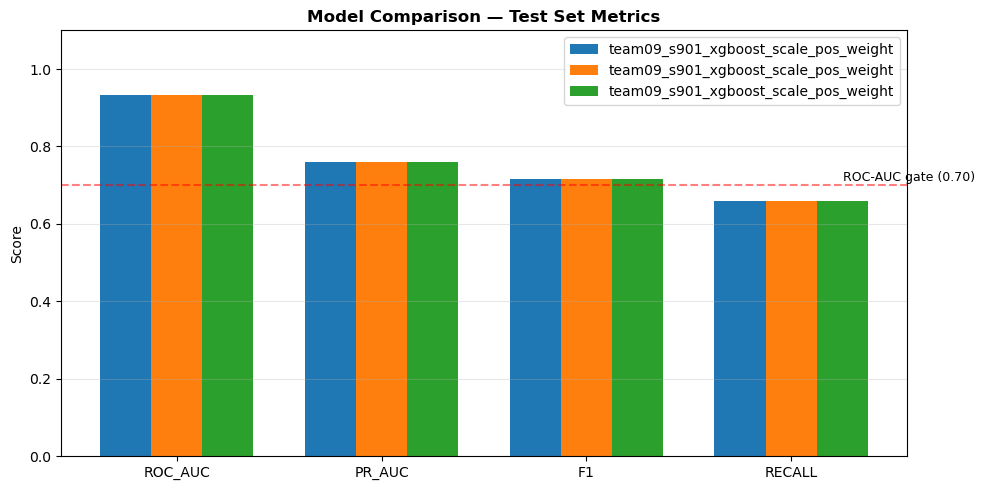

In [18]:
# Visual comparison of top completed runs in the current experiment.
fig, ax = plt.subplots(figsize=(10, 5))

metric_cols = [
    "metrics.test_roc_auc",
    "metrics.test_pr_auc",
    "metrics.test_f1",
    "metrics.test_recall",
]
avail_m = [c for c in metric_cols if c in runs.columns]

# Use the top 3 finished runs by AUC.
top_runs = runs.head(3)

labels = [c.replace("metrics.test_", "").upper() for c in avail_m]
x = np.arange(len(labels))
w = 0.25

for idx, (_, row) in enumerate(top_runs.iterrows()):
    vals = [row.get(m, 0) for m in avail_m]
    ax.bar(x + idx * w, vals, w, label=row.get("tags.mlflow.runName", f"run{idx}"))

ax.set_xticks(x + w)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Metrics", fontweight="bold")
ax.axhline(0.70, linestyle="--", alpha=0.5, color="red")
ax.text(len(labels) - 0.5, 0.71, "ROC-AUC gate (0.70)", fontsize=9)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
# ==========================================================
# Quality Gate and Best Model Selection
# ==========================================================
# PR-AUC is used as the primary gate metric because it is more
# meaningful than ROC-AUC for imbalanced fraud detection (5.5%)
# ROC-AUC is checked as a secondary sanity gate

QUALITY_GATE_PR_AUC = 0.70
QUALITY_GATE_ROC = 0.70

print("=" * 60)
print("QUALITY GATE")
print("=" * 60)

pr_ok = BEST_PR_AUC >= QUALITY_GATE_PR_AUC
roc_ok = BEST_ROC >= QUALITY_GATE_ROC

if not pr_ok or not roc_ok:
    print(f"❌ Quality gate FAILED")
    print(f"Best test PR-AUC : {BEST_PR_AUC:.4f} (required >= {QUALITY_GATE_PR_AUC}): {'PASS' if pr_ok else 'FAIL'}")
    print(f"Best test ROC-AUC : {BEST_ROC:.4f} (required >= {QUALITY_GATE_ROC}): {'PASS' if roc_ok else 'FAIL'}")
    print("\nReview feature engineering or hyperparameters before proceeding.")
    BEST_MODEL_URI = None
else:
    print(f"✅ Quality gate PASSED")
    print(f"Best test PR-AUC : {BEST_PR_AUC:.4f} (required >= {QUALITY_GATE_PR_AUC})")
    print(f"Best test ROC-AUC : {BEST_ROC:.4f} (required >= {QUALITY_GATE_ROC})")


    # Export information for Notebook 03
    BEST_MODEL_URI = f"runs:/{BEST_RUN_ID}/model"

    print("\nBest MLflow Run")
    print("-" * 60)
    print(f"Run Name    : {BEST_RUN_NAME}")
    print(f"Run ID      : {BEST_RUN_ID}")
    print(f"Model URI   : {BEST_MODEL_URI}")
    print(f"Best PR-AUC : {BEST_PR_AUC:.4f}")
    print(f"Best ROC    : {BEST_ROC:.4f}")

print("=" * 60)

QUALITY GATE
✅ Quality gate PASSED
Best test PR-AUC : 0.7592 (required >= 0.7)
Best test ROC-AUC : 0.9318 (required >= 0.7)

Best MLflow Run
------------------------------------------------------------
Run Name    : team09_s901_xgboost_scale_pos_weight
Run ID      : 0e981f363e1a4869a213355b861f0670
Model URI   : runs:/0e981f363e1a4869a213355b861f0670/model
Best PR-AUC : 0.7592
Best ROC    : 0.9318


In [20]:
# ==========================================================
# Notebook 03 Inputs
# ==========================================================
print("\nCopy these values into Notebook 03 if required:\n")
print(f'BEST_RUN_ID    = "{BEST_RUN_ID}"')

if BEST_MODEL_URI is not None:
    print(f'BEST_MODEL_URI = "{BEST_MODEL_URI}"')

print(f"Best PR-AUC    = {BEST_PR_AUC:.4f}")
print(f"BEST_ROC       = {BEST_ROC:.4f}")
print(f'BEST_RUN_NAME  = "{BEST_RUN_NAME}"')


Copy these values into Notebook 03 if required:

BEST_RUN_ID    = "0e981f363e1a4869a213355b861f0670"
BEST_MODEL_URI = "runs:/0e981f363e1a4869a213355b861f0670/model"
Best PR-AUC    = 0.7592
BEST_ROC       = 0.9318
BEST_RUN_NAME  = "team09_s901_xgboost_scale_pos_weight"


In [21]:
# Write to JSON file so Notebook 03 can read it.
best_model_info = {
    "team_id": TEAM_ID,
    "student_id": STUDENT_ID,
    "project_name": PROJECT_NAME,
    "best_run_id": BEST_RUN_ID,
    "best_run_name": BEST_RUN_NAME,
    "best_roc": float(BEST_ROC),
    "best_pr_auc": float(BEST_PR_AUC),
    "best_model_uri": BEST_MODEL_URI,
    "mlflow_tracking_uri": MLFLOW_APP_ARN,
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "tracking_backend": "sagemaker_mlflow_app",
    "mlflow_app_team_tag": TEAM_ID,
}

with open("best_model.json", "w") as f:
    json.dump(best_model_info, f, indent=4)

print("Saved best model information to best_model.json")
print(json.dumps(best_model_info, indent=2))

Saved best model information to best_model.json
{
  "team_id": "team09",
  "student_id": "s901",
  "project_name": "bank-fraud-detection",
  "best_run_id": "0e981f363e1a4869a213355b861f0670",
  "best_run_name": "team09_s901_xgboost_scale_pos_weight",
  "best_roc": 0.9318,
  "best_pr_auc": 0.7592,
  "best_model_uri": "runs:/0e981f363e1a4869a213355b861f0670/model",
  "mlflow_tracking_uri": "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YLZFIPQTQXFU",
  "mlflow_experiment": "ITI113/team09/Experiment1",
  "tracking_backend": "sagemaker_mlflow_app",
  "mlflow_app_team_tag": "team09"
}


In [22]:
client = MlflowClient()
artifacts = client.list_artifacts(BEST_RUN_ID)

for a in artifacts:
    print(a.path, a.is_dir)

plots True


In [23]:
# Load best model directly from the best MLflow run and test inference
loaded = mlflow.sklearn.load_model(BEST_MODEL_URI)

client = MlflowClient()
run = client.get_run(BEST_RUN_ID)
best_threshold = float(run.data.metrics.get("best_threshold", 0.5))
print(f"F1-tuned threshold for best run: {best_threshold:.4f}")

sample = X_test.head(5)
probas = loaded.predict_proba(sample)[:, 1]
preds = (probas >= best_threshold).astype(int)

results = pd.DataFrame(
    {
        "actual": y_test.head(5).values,
        "predicted": preds,
        "probability": probas.round(3),
        "correct": preds == y_test.head(5).values,
    }
)

print("Sample predictions from best MLflow run model:")
print(results.to_string(index=False))

F1-tuned threshold for best run: 0.8865
Sample predictions from best MLflow run model:
 actual  predicted  probability  correct
      0          0        0.405     True
      0          0        0.263     True
      1          0        0.244    False
      0          1        0.986    False
      0          0        0.162     True


In [25]:
# Define metric functions outside the loop
metric_fns = {
    "selection_rate": selection_rate,
    "accuracy": accuracy_score,
    "precision": lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
    "recall": lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
    "f1": lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
    "fpr": false_positive_rate,
    "fnr": false_negative_rate,
}

BEST_THRESHOLD = best_threshold
y_prob = best_xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

fairness_results = {}

for attr in PROTECTED_ATTRIBUTES:
    sensitive = X_test[attr].astype(str)

    mf = MetricFrame(
        metrics=metric_fns,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive,
    )

    dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive)
    dp_ratio = demographic_parity_ratio(y_test, y_pred, sensitive_features=sensitive)
    eo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive)
    eo_ratio = equalized_odds_ratio(y_test, y_pred, sensitive_features=sensitive)

    fairness_results[attr] = {
        "metric_frame": mf,
        "demographic_parity_difference": dp_diff,
        "demographic_parity_ratio": dp_ratio,
        "equalized_odds_difference": eo_diff,
        "equalized_odds_ratio": eo_ratio,
    }

    print("=" * 70)
    print(f"FAIRNESS ANALYSIS: {attr}")
    print("=" * 70)
    print("\nPer-group metrics:")
    print(mf.by_group.round(4).to_string())
    print("\nOverall fairness metrics:")
    print(f"Demographic Parity Difference : {dp_diff:.4f}")
    print(f"Demographic Parity Ratio      : {dp_ratio:.4f}")
    print(f"Equalized Odds Difference     : {eo_diff:.4f}")
    print(f"Equalized Odds Ratio          : {eo_ratio:.4f}")

    if dp_ratio >= 0.8:
        print(" -> Demographic Parity: PASS (ratio >= 0.8 four-fifths rule)")
    else:
        print(" -> Demographic Parity: REVIEW NEEDED (ratio < 0.8)")
    print()

FAIRNESS ANALYSIS: customer_age_group

Per-group metrics:
                    selection_rate  accuracy  precision  recall      f1     fpr     fnr
customer_age_group                                                                     
18-25                       0.0251    0.9669     0.9841  0.4299  0.5984  0.0004  0.5701
26-40                       0.0242    0.9676     0.9575  0.4249  0.5886  0.0011  0.5751
41-60                       0.0236    0.9680     0.9657  0.4223  0.5877  0.0009  0.5777
60+                         0.0246    0.9659     0.9721  0.4167  0.5834  0.0007  0.5833

Overall fairness metrics:
Demographic Parity Difference : 0.0015
Demographic Parity Ratio      : 0.9421
Equalized Odds Difference     : 0.0131
Equalized Odds Ratio          : 0.3883
 -> Demographic Parity: PASS (ratio >= 0.8 four-fifths rule)



FAIRNESS ANALYSIS: is_international

Per-group metrics:
                  selection_rate  accuracy  precision  recall      f1     fpr     fnr
is_international                                                                     
0                         0.0093    0.9768     0.9636  0.2805  0.4345  0.0003  0.7195
1                         0.0987    0.9209     0.9669  0.5573  0.7071  0.0039  0.4427

Overall fairness metrics:
Demographic Parity Difference : 0.0895
Demographic Parity Ratio      : 0.0937
Equalized Odds Difference     : 0.2768
Equalized Odds Ratio          : 0.0883
 -> Demographic Parity: REVIEW NEEDED (ratio < 0.8)



FAIRNESS ANALYSIS: device_type

Per-group metrics:
              selection_rate  accuracy  precision  recall      f1     fpr     fnr
device_type                                                                      
ATM                   0.0247    0.9667     0.9639  0.4237  0.5886  0.0009  0.5763
Desktop               0.0234    0.9678     0.9691  0.4193  0.5854  0.0008  0.5807
Mobile                0.0245    0.9678     0.9685  0.4294  0.5950  0.0008  0.5706
POS Terminal          0.0240    0.9658     0.9580  0.4093  0.5736  0.0011  0.5907
Tablet                0.0237    0.9682     0.9558  0.4235  0.5869  0.0011  0.5765

Overall fairness metrics:
Demographic Parity Difference : 0.0013
Demographic Parity Ratio      : 0.9487
Equalized Odds Difference     : 0.0200
Equalized Odds Ratio          : 0.6929
 -> Demographic Parity: PASS (ratio >= 0.8 four-fifths rule)



FAIRNESS ANALYSIS: country

Per-group metrics:
           selection_rate  accuracy  precision  recall      f1     fpr     fnr
country                                                                       
Australia          0.0242    0.9658     0.9667  0.4121  0.5778  0.0009  0.5879
Brazil             0.0235    0.9651     0.9624  0.3987  0.5638  0.0009  0.6013
Canada             0.0239    0.9685     0.9727  0.4297  0.5961  0.0007  0.5703
France             0.0241    0.9689     0.9764  0.4350  0.6018  0.0006  0.5650
Germany            0.0233    0.9654     0.9838  0.4013  0.5701  0.0004  0.5987
India              0.0238    0.9681     0.9720  0.4259  0.5923  0.0007  0.5741
Japan              0.0219    0.9690     0.9635  0.4108  0.5760  0.0008  0.5892
Mexico             0.0244    0.9690     0.9595  0.4383  0.6017  0.0010  0.5617
UK                 0.0233    0.9672     0.9680  0.4124  0.5783  0.0008  0.5876
USA                0.0254    0.9677     0.9571  0.4374  0.6004  0.0012  0.5626

Over

FAIRNESS ANALYSIS: city

Per-group metrics:
             selection_rate  accuracy  precision  recall      f1     fpr     fnr
city                                                                            
Berlin               0.0233    0.9682     0.9612  0.4200  0.5845  0.0010  0.5800
Delhi                0.0223    0.9657     0.9864  0.3931  0.5622  0.0003  0.6069
Guadalajara          0.0225    0.9661     0.9733  0.3960  0.5630  0.0006  0.6040
London               0.0239    0.9702     0.9747  0.4442  0.6103  0.0006  0.5558
Los Angeles          0.0231    0.9693     0.9655  0.4275  0.5926  0.0008  0.5725
Lyon                 0.0246    0.9675     0.9502  0.4272  0.5894  0.0013  0.5728
Manchester           0.0223    0.9655     0.9646  0.3900  0.5554  0.0008  0.6100
Melbourne            0.0249    0.9704     0.9718  0.4556  0.6203  0.0007  0.5444
Mexico City          0.0250    0.9680     0.9640  0.4366  0.6010  0.0010  0.5634
Mumbai               0.0245    0.9662     0.9719  0.4187  0.5852 

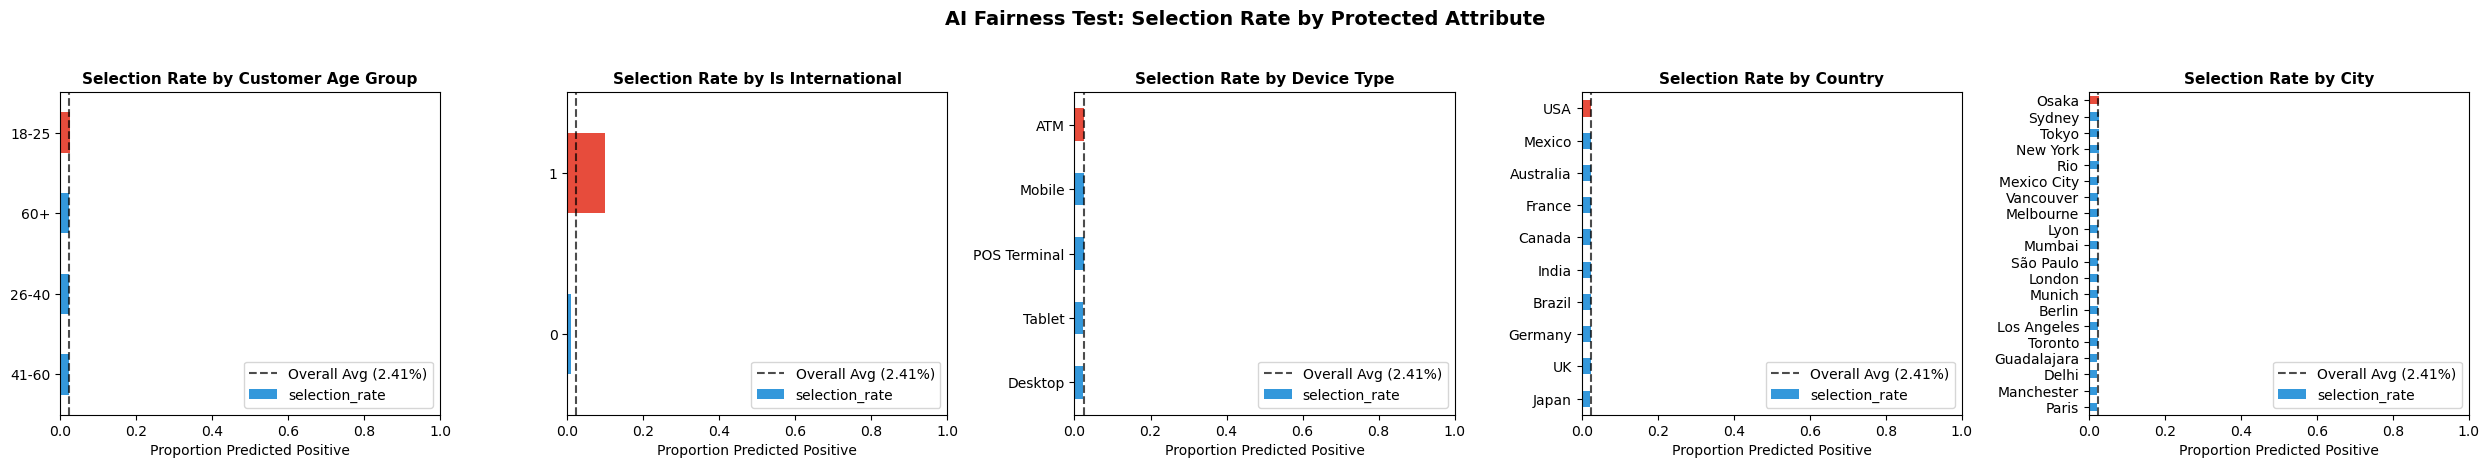

In [26]:
fig, axes = plt.subplots(
    1, len(PROTECTED_ATTRIBUTES), figsize=(5 * len(PROTECTED_ATTRIBUTES), 4.5)
)

# Standardize single-subplot or multi-subplot indexing
if len(PROTECTED_ATTRIBUTES) == 1:
    axes = np.array([axes])
else:
    axes = axes.ravel()

for idx, attr in enumerate(PROTECTED_ATTRIBUTES):
    mf = fairness_results[attr]["metric_frame"]
    sr = mf.by_group["selection_rate"].sort_values()
    
    # Highlight highest selection rate in red, others in blue
    colors = ["#E74C3C" if v == sr.max() else "#3498DB" for v in sr.values]

    sr.plot(kind="barh", ax=axes[idx], color=colors, xlim=(0, 1.0))
    axes[idx].set_title(f"Selection Rate by {attr.replace('_', ' ').title()}", fontweight="bold", fontsize=11)
    axes[idx].set_xlabel("Proportion Predicted Positive")
    axes[idx].set_ylabel("")

    # True overall selection rate across all groups
    overall_rate = mf.overall["selection_rate"]
    axes[idx].axvline(
        x=overall_rate,
        color="black",
        linestyle="--",
        alpha=0.7,
        label=f"Overall Avg ({overall_rate:.2%})"
    )
    axes[idx].legend(loc="lower right")

plt.suptitle(
    "AI Fairness Test: Selection Rate by Protected Attribute",
    fontweight="bold",
    fontsize=14,
    y=1.03,
)

plt.tight_layout()
plt.savefig("fairness_selection_rate.png", dpi=150, bbox_inches="tight")
plt.show()

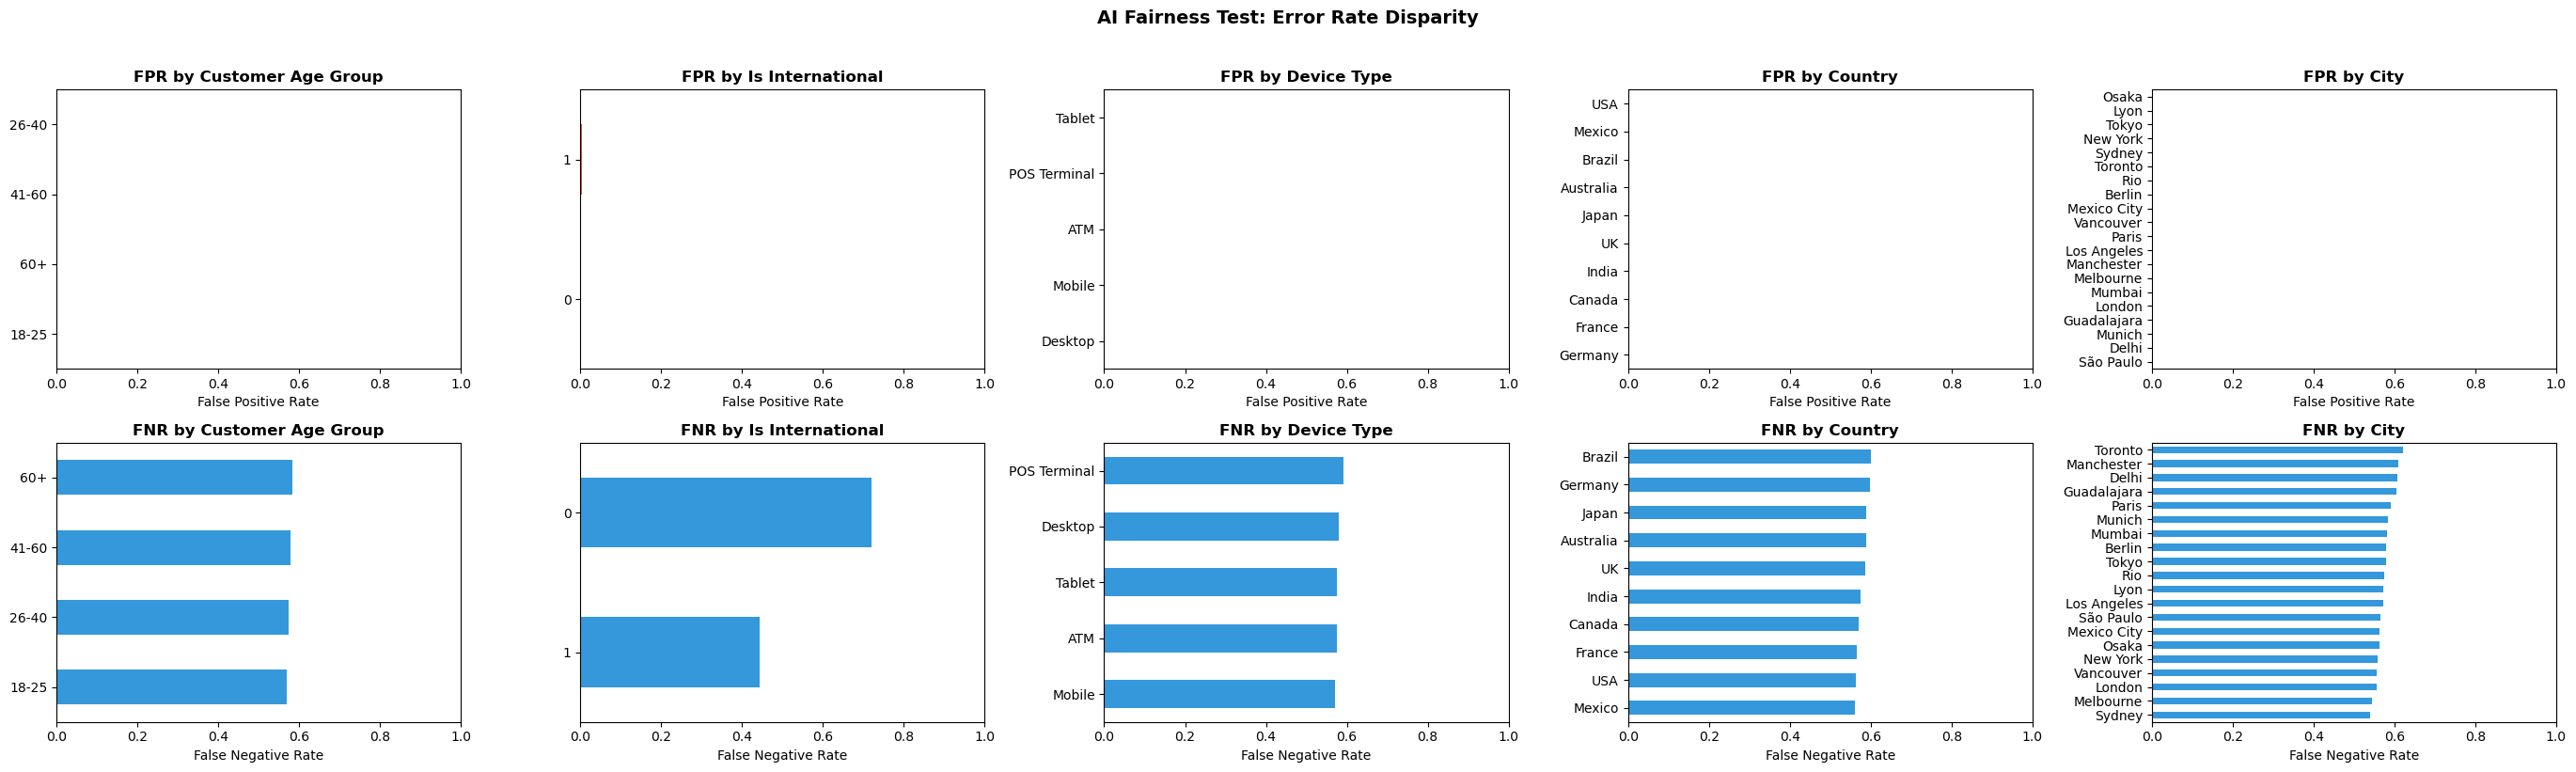

In [27]:
fig, axes = plt.subplots(
    2, len(PROTECTED_ATTRIBUTES), figsize=(5.5 * len(PROTECTED_ATTRIBUTES), 8)
)

# Ensure 2D array indexing axes[row, col] works for len == 1
if len(PROTECTED_ATTRIBUTES) == 1:
    axes = np.array(axes).reshape(2, 1)

for idx, attr in enumerate(PROTECTED_ATTRIBUTES):
    mf = fairness_results[attr]["metric_frame"]

    # --- False Positive Rate (FPR) ---
    fpr = mf.by_group["fpr"].sort_values()
    fpr.plot(kind="barh", ax=axes[0, idx], color="#E74C3C", xlim=(0, 1.0))
    axes[0, idx].set_title(f"FPR by {attr.replace('_', ' ').title()}", fontweight="bold")
    axes[0, idx].set_xlabel("False Positive Rate")
    axes[0, idx].set_ylabel("")

    # --- False Negative Rate (FNR) ---
    fnr = mf.by_group["fnr"].sort_values()  # Fixed: Changed "fpr" to "fnr"
    fnr.plot(kind="barh", ax=axes[1, idx], color="#3498DB", xlim=(0, 1.0))  # Fixed: Target axes[1, idx]
    axes[1, idx].set_title(f"FNR by {attr.replace('_', ' ').title()}", fontweight="bold")
    axes[1, idx].set_xlabel("False Negative Rate")
    axes[1, idx].set_ylabel("")

plt.suptitle(
    "AI Fairness Test: Error Rate Disparity",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.savefig("fairness_error_rate.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
fairness_summary_rows = []

for attr in PROTECTED_ATTRIBUTES:
    r = fairness_results[attr]
    
    # Safely extract and handle possible NaN values
    dp_ratio = r["demographic_parity_ratio"]
    eo_ratio = r["equalized_odds_ratio"]

    # Handle threshold evaluations safely with np.isnan
    dp_pass = "PASS" if (not np.isnan(dp_ratio) and dp_ratio >= 0.8) else ("N/A" if np.isnan(dp_ratio) else "REVIEW")
    eo_pass = "PASS" if (not np.isnan(eo_ratio) and eo_ratio >= 0.8) else ("N/A" if np.isnan(eo_ratio) else "REVIEW")

    fairness_summary_rows.append({
        "Protected Attribute": attr,
        "Demographic Parity Diff": round(r["demographic_parity_difference"], 4),
        "Demographic Parity Ratio": round(dp_ratio, 4),
        "Equalized Odds Diff": round(r["equalized_odds_difference"], 4),
        "Equalized Odds Ratio": round(eo_ratio, 4),
        "DP Status (4/5 Rule)": dp_pass,
        "EO Status": eo_pass,
    })

fairness_summary = pd.DataFrame(fairness_summary_rows)

print("\n" + "=" * 70)
print("FAIRNESS TEST SUMMARY (AI VERIFY FRAMEWORK)")
print("=" * 70)
print(fairness_summary.to_string(index=False))


FAIRNESS TEST SUMMARY (AI VERIFY FRAMEWORK)
Protected Attribute  Demographic Parity Diff  Demographic Parity Ratio  Equalized Odds Diff  Equalized Odds Ratio DP Status (4/5 Rule) EO Status
 customer_age_group                   0.0015                    0.9421               0.0131                0.3883                 PASS    REVIEW
   is_international                   0.0895                    0.0937               0.2768                0.0883               REVIEW    REVIEW
        device_type                   0.0013                    0.9487               0.0200                0.6929                 PASS    REVIEW
            country                   0.0035                    0.8618               0.0396                0.3480                 PASS    REVIEW
               city                   0.0044                    0.8338               0.0801                0.2100                 PASS    REVIEW


In [31]:
NUMERIC_FEATURES = [
    "hour_of_day",
    "customer_age",
    "credit_score",
    "account_age_years",
    "account_balance",
    "transaction_amount",
    "num_prev_transactions",
    "transaction_freq_monthly",
    "distance_from_home_km",
    "time_since_last_txn_hrs",
    "failed_attempts",
    "log_transaction_amount",
    "log_account_balance",
    "amount_to_balance_ratio",
    "risk_score",
    "failed_x_transaction",
    "night_x_international",
    "pin_x_failed",
    "night_x_pin",
    "amount_x_distance",
    "amount_x_failed",
    "risk_x_amount",
    "risk_x_distance",
    "customer_mean_amount",
    "customer_std_amount",
    "customer_mean_distance",
    "customer_std_distance",
    "customer_txn_count",
    "customer_mean_balance",
    "amount_zscore",
    "distance_zscore",
    "balance_deviation",
]

ROBUST_SAMPLE_SIZE = 5000
np.random.seed(RANDOM_STATE)

# Fixed min() syntax
sample_size = min(ROBUST_SAMPLE_SIZE, len(X_test))
robust_idx = np.random.choice(len(X_test), size=sample_size, replace=False)
X_robust = X_test.iloc[robust_idx].copy()

baseline_probs = best_xgb_model.predict_proba(X_robust)[:, 1]
baseline_preds = (baseline_probs >= BEST_THRESHOLD).astype(int)

perturbation_results = []

for feat in NUMERIC_FEATURES:
    if feat not in X_robust.columns:
        continue

    feat_std = X_robust[feat].std()

    # Fixed equality operator == and missing colon
    if feat_std == 0 or pd.isna(feat_std):
        continue

    # Fixed DataFrame copy and +1 std perturbation
    X_perturbed = X_robust.copy()
    X_perturbed[feat] = X_perturbed[feat] + feat_std

    # Generated perturbed predictions
    perturbed_probs = best_xgb_model.predict_proba(X_perturbed)[:, 1]
    perturbed_preds = (perturbed_probs >= BEST_THRESHOLD).astype(int)

    # Calculate metrics
    prob_change = np.abs(perturbed_probs - baseline_probs).mean()
    pred_flip_rate = np.mean(perturbed_preds != baseline_preds)

    # Fixed missing comma in dict
    perturbation_results.append({
        "feature": feat,
        "std_used": round(float(feat_std), 4),
        "mean_prob_change": round(float(prob_change), 4),
        "prediction_flip_rate": round(float(pred_flip_rate), 4),
    })

pert_df = pd.DataFrame(perturbation_results).sort_values("mean_prob_change", ascending=False)
print("\nFeature Perturbation Results (+1 std):")
print(pert_df.to_string(index=False))


Feature Perturbation Results (+1 std):
                 feature   std_used  mean_prob_change  prediction_flip_rate
         failed_attempts     1.1449            0.3776                0.0324
              risk_score     0.8538            0.1629                0.0026
         risk_x_distance    62.4731            0.0861                0.0022
      customer_txn_count     1.6859            0.0278                0.0034
            pin_x_failed     0.5783            0.0261                0.0026
    failed_x_transaction     0.7153            0.0215                0.0026
 time_since_last_txn_hrs    11.9699            0.0174                0.0084
transaction_freq_monthly     4.4428            0.0170                0.0022
   num_prev_transactions    12.1543            0.0156                0.0020
             night_x_pin     0.1858            0.0153                0.0018
            credit_score    79.5550            0.0153                0.0022
   night_x_international     0.2535            0

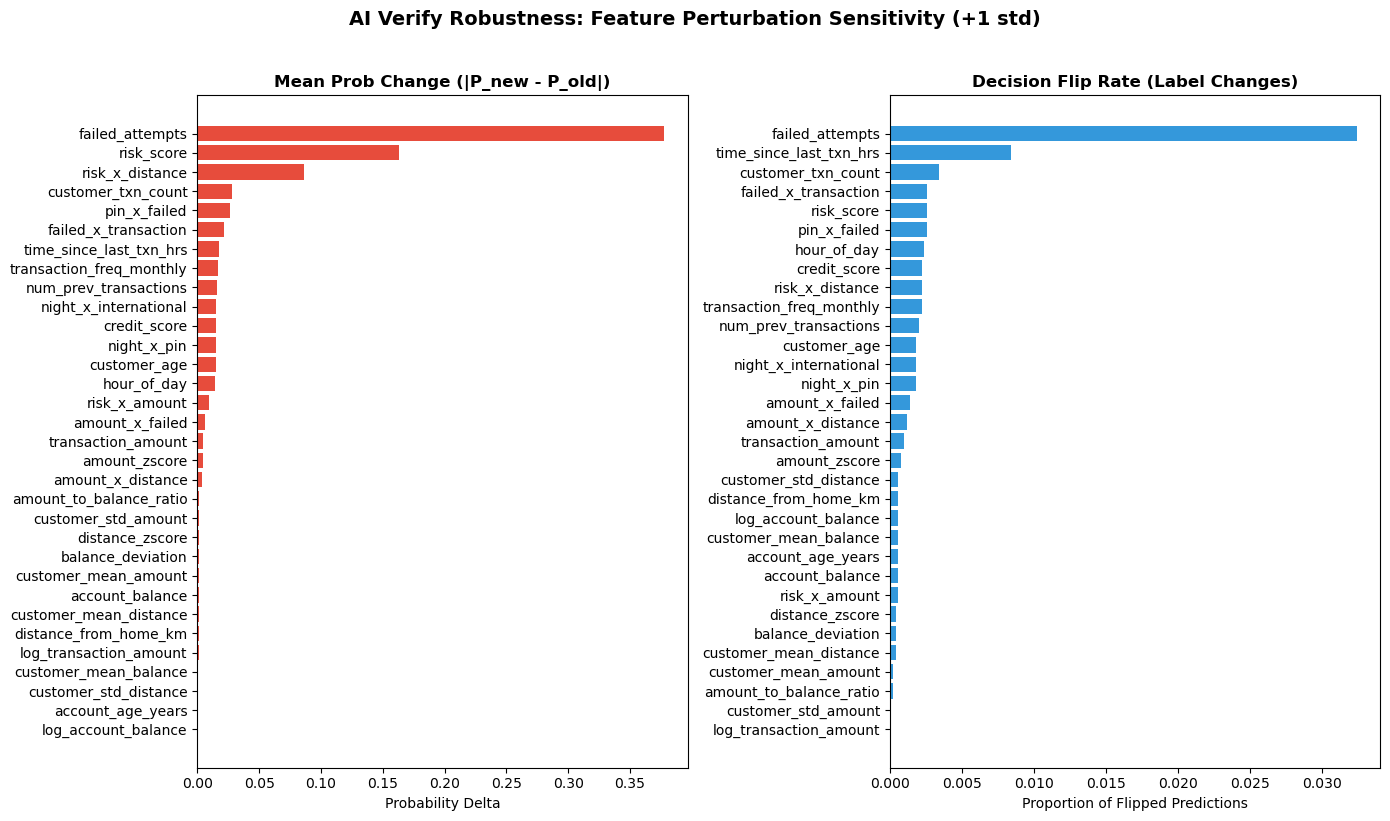

In [44]:
# Perturbation sensitivity visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Sort features so highest impact appears at the top
pert_sorted_prob = pert_df.sort_values("mean_prob_change")
pert_sorted_flip = pert_df.sort_values("prediction_flip_rate")

# Plot 1: Mean Absolute Probability Change
ax1.barh(pert_sorted_prob["feature"], pert_sorted_prob["mean_prob_change"], color="#E74C3C")
ax1.set_title("Mean Prob Change (|P_new - P_old|)", fontweight="bold")
ax1.set_xlabel("Probability Delta")

# Plot 2: Prediction Flip Rate
ax2.barh(pert_sorted_flip["feature"], pert_sorted_flip["prediction_flip_rate"], color="#3498DB")
ax2.set_title("Decision Flip Rate (Label Changes)", fontweight="bold")
ax2.set_xlabel("Proportion of Flipped Predictions")

plt.suptitle(
    "AI Verify Robustness: Feature Perturbation Sensitivity (+1 std)",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.savefig("robustness_perturbation.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# Gaussian Noise Injection Robustness
# Add increasing levels of Gaussian noise to all numeric features and measure degradation
print("--- AI Verify Robustness: Gaussian Noise Injection ---")

# Set random seed for reproducibility
np.random.seed(42)

noise_levels = [0.01, 0.05, 0.10, 0.20, 0.50]
noise_results = []

available_numeric = [f for f in NUMERIC_FEATURES if f in X_robust.columns]

for noise_scale in noise_levels:
    X_noisy = X_robust.copy()

    # Add Gaussian noise scaled by feature std
    for feat in available_numeric:
        feat_std = X_robust[feat].std()  # Fixed reference from X_noise to X_robust
        if feat_std > 0 and not pd.isna(feat_std):
            noise = np.random.normal(0, noise_scale * feat_std, len(X_noisy))
            X_noisy[feat] = X_noisy[feat] + noise

    noisy_probs = best_xgb_model.predict_proba(X_noisy)[:, 1]
    noisy_preds = (noisy_probs >= BEST_THRESHOLD).astype(int)

    prob_change = np.abs(noisy_probs - baseline_probs).mean()
    flip_rate = (noisy_preds != baseline_preds).mean()
    accuracy = accuracy_score(y_test.iloc[robust_idx], noisy_preds)
    f1 = f1_score(y_test.iloc[robust_idx], noisy_preds, zero_division=0)

    noise_results.append({
        "noise_scale": noise_scale,
        "mean_prob_change": round(float(prob_change), 4),  # Fixed typo
        "prediction_flip_rate": round(float(flip_rate), 4),
        "accuracy": round(float(accuracy), 4),
        "f1_score": round(float(f1), 4)
    })

noise_df = pd.DataFrame(noise_results)
print("\nGaussian Noise Injection Results:")
print(noise_df.to_string(index=False))

--- AI Verify Robustness: Gaussian Noise Injection ---



Gaussian Noise Injection Results:
 noise_scale  mean_prob_change  prediction_flip_rate  accuracy  f1_score
        0.01            0.2060                0.0092    0.9692    0.6385
        0.05            0.3031                0.0150    0.9670    0.6374
        0.10            0.3344                0.0182    0.9642    0.6200
        0.20            0.3673                0.0206    0.9666    0.6542
        0.50            0.3879                0.0356    0.9508    0.5560


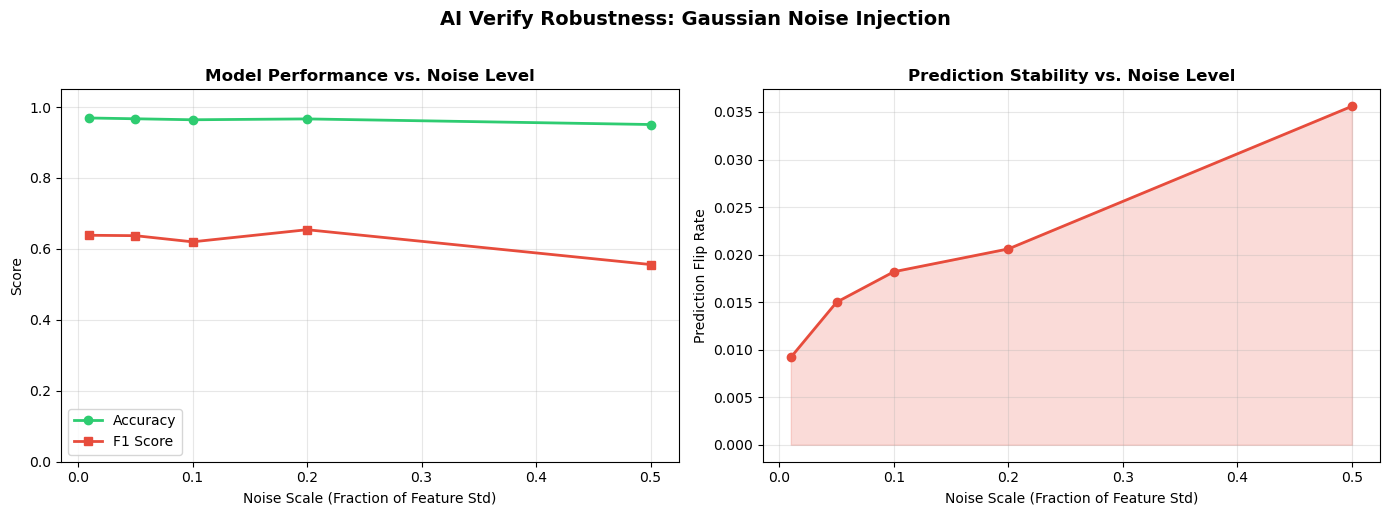

In [43]:
# Noise robustness visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Performance Decay
ax1.plot(noise_df["noise_scale"], noise_df["accuracy"], "o-", color="#2ECC71", label="Accuracy", linewidth=2)
ax1.plot(noise_df["noise_scale"], noise_df["f1_score"], "s-", color="#E74C3C", label="F1 Score", linewidth=2)
ax1.set_xlabel("Noise Scale (Fraction of Feature Std)")
ax1.set_ylabel("Score")
ax1.set_title("Model Performance vs. Noise Level", fontweight="bold")
ax1.legend(loc="lower left")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.3)

# Plot 2: Prediction Stability
ax2.plot(noise_df["noise_scale"], noise_df["prediction_flip_rate"], "o-", color="#E74C3C", linewidth=2)
# Fixed typo: 'olor' -> 'color'
ax2.fill_between(noise_df["noise_scale"], 0, noise_df["prediction_flip_rate"], color="#E74C3C", alpha=0.2)
ax2.set_xlabel("Noise Scale (Fraction of Feature Std)")
ax2.set_ylabel("Prediction Flip Rate")
ax2.set_title("Prediction Stability vs. Noise Level", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.suptitle(
    "AI Verify Robustness: Gaussian Noise Injection",
    fontweight="bold",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.savefig("robustness_noise.png", dpi=150, bbox_inches="tight")
plt.show()

--- AI Verify Robustness: Decision Boundary Analysis ---


Decision threshold: 0.8865
Transactions within +/- 0.05 of threshold: 1442 (0.72%)

Boundary region performance:
  Accuracy  : 0.5943
  F1 Score  : 0.7237
  Precision : 0.9001
  Recall    : 0.6051
  Actual fraud rate in boundary : 87.79%


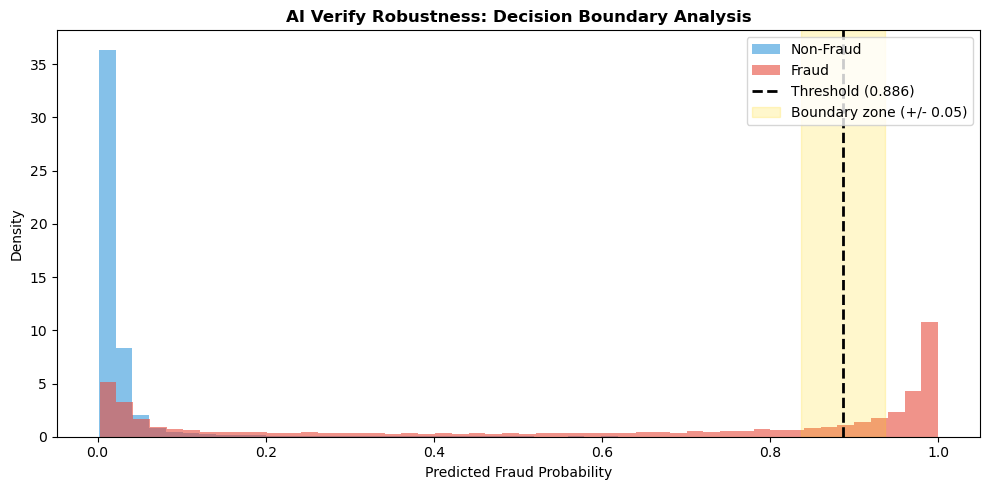

In [39]:
print("--- AI Verify Robustness: Decision Boundary Analysis ---")

full_probs = best_xgb_model.predict_proba(X_test)[:, 1]

# Set a realistic margin around the decision threshold (e.g., +/- 0.05)
MARGIN = 0.05
near_boundary_mask = np.abs(full_probs - BEST_THRESHOLD) <= MARGIN
n_near_boundary = near_boundary_mask.sum()

print(f"Decision threshold: {BEST_THRESHOLD:.4f}")
print(
    f"Transactions within +/- {MARGIN} of threshold: {n_near_boundary} "
    f"({(n_near_boundary / len(full_probs)) * 100:.2f}%)"
)

if n_near_boundary > 0:
    boundary_actual = y_test[near_boundary_mask]
    boundary_probs = full_probs[near_boundary_mask]
    boundary_preds = (boundary_probs >= BEST_THRESHOLD).astype(int)

    print("\nBoundary region performance:")
    print(f"  Accuracy  : {accuracy_score(boundary_actual, boundary_preds):.4f}")
    print(f"  F1 Score  : {f1_score(boundary_actual, boundary_preds, zero_division=0):.4f}")
    print(f"  Precision : {precision_score(boundary_actual, boundary_preds, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(boundary_actual, boundary_preds, zero_division=0):.4f}")
    print(f"  Actual fraud rate in boundary : {boundary_actual.mean() * 100:.2f}%")

# Distribution of prediction probabilities
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(full_probs[y_test == 0], bins=50, alpha=0.6, color="#3498DB", label="Non-Fraud", density=True)
ax.hist(full_probs[y_test == 1], bins=50, alpha=0.6, color="#E74C3C", label="Fraud", density=True)

ax.axvline(
    x=BEST_THRESHOLD, 
    linestyle="--", 
    color="black", 
    label=f"Threshold ({BEST_THRESHOLD:.3f})", 
    linewidth=2
)
ax.axvspan(
    max(0, BEST_THRESHOLD - MARGIN), 
    min(1, BEST_THRESHOLD + MARGIN), 
    alpha=0.2, 
    color="gold", 
    label=f"Boundary zone (+/- {MARGIN})"
)

ax.set_xlabel("Predicted Fraud Probability")
ax.set_ylabel("Density")
ax.set_title("AI Verify Robustness: Decision Boundary Analysis", fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("robustness_boundary_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
print("=" * 70)
print("ROBUSTNESS TEST SUMMARY (AI VERIFY FRAMEWORK)")
print("=" * 70)

# Feature sensitivity assessment (Fixed dataframe variable: pert_df)
max_flip = pert_df["prediction_flip_rate"].max()
max_prob_change = pert_df["mean_prob_change"].max()

print("1. Feature Perturbation (+1 std):")
print(f"   Max prediction flip rate : {max_flip:.4f}")
print(f"   Max mean prob change     : {max_prob_change:.4f}")
print(f"   Most sensitive feature   : {pert_df.iloc[0]['feature']}")

# Noise injection assessment
noise_10pct = noise_df[noise_df["noise_scale"] == 0.10].iloc[0]
print("\n2. Gaussian Noise (10% of std):")
print(f"   Accuracy                 : {noise_10pct['accuracy']:.4f}")
print(f"   F1 Score                 : {noise_10pct['f1_score']:.4f}")
print(f"   Prediction flip rate     : {noise_10pct['prediction_flip_rate']:.4f}")

# Overall robustness assessment
if noise_10pct['accuracy'] >= 0.95 and max_flip <= 0.15:
    robustness_status = "PASS"
    print("\nOverall Robustness: PASS")
    print(" -> Model maintains high accuracy under moderate perturbation.")
elif noise_10pct['accuracy'] >= 0.90:
    robustness_status = "ACCEPTABLE"
    print("\nOverall Robustness: ACCEPTABLE")
    print(" -> Model shows moderate sensitivity; monitoring recommended.")
else:
    robustness_status = "REVIEW"
    print("\nOverall Robustness: REVIEW NEEDED")
    print(" -> Model shows significant sensitivity to perturbations.")

ROBUSTNESS TEST SUMMARY (AI VERIFY FRAMEWORK)
1. Feature Perturbation (+1 std):
   Max prediction flip rate : 0.0324
   Max mean prob change     : 0.3776
   Most sensitive feature   : failed_attempts

2. Gaussian Noise (10% of std):
   Accuracy                 : 0.9642
   F1 Score                 : 0.6200
   Prediction flip rate     : 0.0182

Overall Robustness: PASS
 -> Model maintains high accuracy under moderate perturbation.


In [41]:
print("=" * 55)
print("NOTEBOOK 02 COMPLETE")
print("=" * 55)
print(f"Experiment : {MLFLOW_EXPERIMENT}")
print(f"MLflow App : {MLFLOW_APP_ARN}")
print(f"Best model : {BEST_RUN_NAME} | PR_AUC={BEST_PR_AUC:.4f} | ROC_AUC={BEST_ROC:.4f}")
print(f"Best run ID: {BEST_RUN_ID}")
print(f"Model URI  : {BEST_MODEL_URI}")
print()
print("Next: Notebook 03 — run the SageMaker Pipeline using the same team S3 folder.")
print(
    "For AWS-native tracking, use the same SageMaker MLflow App ARN in later notebooks."
)

NOTEBOOK 02 COMPLETE
Experiment : ITI113/team09/Experiment1
MLflow App : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-YLZFIPQTQXFU
Best model : team09_s901_xgboost_scale_pos_weight | PR_AUC=0.7592 | ROC_AUC=0.9318
Best run ID: 0e981f363e1a4869a213355b861f0670
Model URI  : runs:/0e981f363e1a4869a213355b861f0670/model

Next: Notebook 03 — run the SageMaker Pipeline using the same team S3 folder.
For AWS-native tracking, use the same SageMaker MLflow App ARN in later notebooks.
